<a href="https://colab.research.google.com/github/WangariLM/telecom_churn_prediction/blob/main/notebooks/LogisticRegressionChurnPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# =============================================================================
# CELL 1: INSTALL LIBRARIES
# We install the two libraries that do not come with Colab by default.
# scikit-learn, pandas, numpy and matplotlib come pre-installed in Colab
# so we only need to add imbalanced-learn for SMOTE and shap for
# model interpretability.
# =============================================================================

!pip install imbalanced-learn --quiet
!pip install shap --quiet

# The exclamation mark before pip tells Colab to run this as a terminal command rather than Python code.
# The --quiet flag suppresses the long installation output so the notebook stays clean.

print("Libraries installed successfully!")

Libraries installed successfully!


In [1]:

# =============================================================================
# CELL 2: IMPORT LIBRARIES
# We import everything we need upfront so the rest of the notebook
# runs without any import errors. This is standard practice — all
# imports at the top so anyone reading the notebook knows exactly
# what is being used.
# =============================================================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn preprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin

# Sklearn model selection
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

# Sklearn model and metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

# Imbalanced learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# SHAP
import shap

# Utilities
import warnings
warnings.filterwarnings("ignore")

# Set consistent plot style for all visualisations
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("All libraries imported successfully!")
print(f"\nKey library versions:")
print(f"  pandas          : {pd.__version__}")
print(f"  numpy           : {np.__version__}")
print(f"  scikit-learn    : {__import__('sklearn').__version__}")
print(f"  imbalanced-learn: {__import__('imblearn').__version__}")
print(f"  shap            : {shap.__version__}")

All libraries imported successfully!

Key library versions:
  pandas          : 2.2.2
  numpy           : 2.0.2
  scikit-learn    : 1.6.1
  imbalanced-learn: 0.14.1
  shap            : 0.51.0


In [2]:

# =============================================================================
# CELL 3: MOUNT DRIVE AND LOAD DATA
# Mount Google Drive to access the dataset used in the
# production project. The data lives in the same folder created
# earlier so do not need to upload anything new.
# =============================================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import zipfile

# Path to the existing project folder in Drive
DATA_PATH = '/content/drive/MyDrive/telecom_churn_prediction/data'

# Check what is in the data folder
print("Files in data folder:")
for f in os.listdir(DATA_PATH):
    size_kb = os.path.getsize(os.path.join(DATA_PATH, f)) / 1024
    print(f"  {f} ({size_kb:.1f} KB)")

# Load the CSV file directly
csv_path = os.path.join(DATA_PATH, 'telco_churn.csv')

# If CSV does not exist extract it from the zip file
if not os.path.exists(csv_path):
    print("\nCSV not found — extracting from zip file...")
    zip_path = os.path.join(DATA_PATH, 'Telco-Customer-Churn.zip')
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(DATA_PATH)
    # Rename extracted file
    for f in os.listdir(DATA_PATH):
        if f.endswith('.csv') and f != 'telco_churn.csv':
            os.rename(
                os.path.join(DATA_PATH, f),
                csv_path
            )
    print("Extracted and renamed successfully!")

# Load the data
df = pd.read_csv(csv_path)

print(f"\nDataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows and {df.shape[1]} columns")
print(f"\nFirst 5 rows:")
display(df.head())

print(f"\nColumn names and data types:")
print(df.dtypes)

Mounted at /content/drive
Files in data folder:
  Telco-Customer-Churn.zip (171.6 KB)
  telco_churn.csv (954.6 KB)

Dataset loaded successfully!
Shape: 7043 rows and 21 columns

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Column names and data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [3]:

# =============================================================================
# CELL 4: DATA CLEANING
# =============================================================================

df_clean = df.copy()

# Drop customerID — just an identifier, no predictive value
df_clean = df_clean.drop(columns=['customerID'])

# Fix TotalCharges — stored as string due to 11 blank values
# Blanks belong to new customers who have never been billed, replace with 0
df_clean['TotalCharges'] = df_clean['TotalCharges'].str.strip().replace('', '0')
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

# Remove 22 duplicate rows
df_clean = df_clean.drop_duplicates(keep='first')

# Encode target — Yes/No to 1/0
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

# Quick sanity check
print(f"Shape       : {df_clean.shape}")
print(f"Nulls       : {df_clean.isnull().sum().sum()}")
print(f"Duplicates  : {df_clean.duplicated().sum()}")
print(f"\nChurn distribution:")
print(df_clean['Churn'].value_counts(normalize=True).mul(100).round(1))

Shape       : (7021, 20)
Nulls       : 0
Duplicates  : 0

Churn distribution:
Churn
0    73.6
1    26.4
Name: proportion, dtype: float64


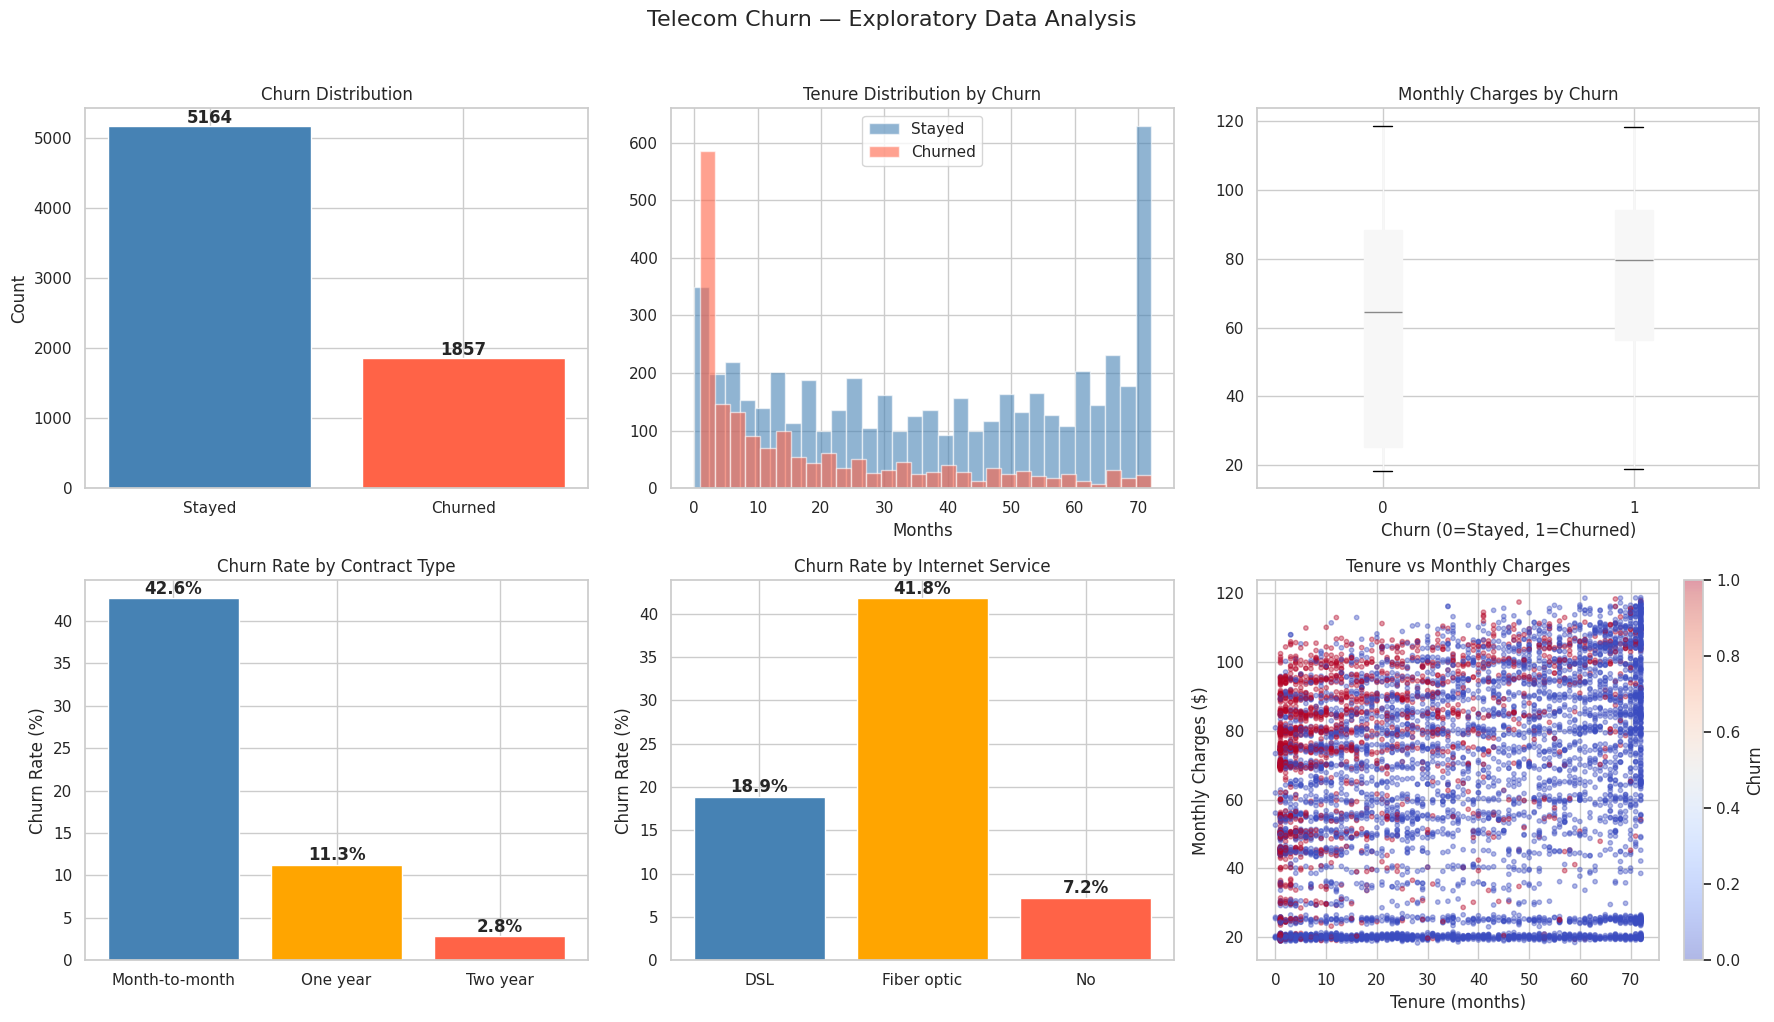

Correlation with Churn:
tenure           -0.351508
TotalCharges     -0.197198
MonthlyCharges    0.194508
Name: Churn, dtype: float64


In [4]:

# =============================================================================
# CELL 5: EXPLORATORY DATA ANALYSIS
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Churn distribution
churn_counts = df_clean['Churn'].value_counts()
axes[0, 0].bar(
    ['Stayed', 'Churned'],
    churn_counts.values,
    color=['steelblue', 'tomato']
)
axes[0, 0].set_title('Churn Distribution')
axes[0, 0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0, 0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Tenure distribution by churn
df_clean[df_clean['Churn'] == 0]['tenure'].hist(
    ax=axes[0, 1], bins=30, alpha=0.6,
    color='steelblue', label='Stayed'
)
df_clean[df_clean['Churn'] == 1]['tenure'].hist(
    ax=axes[0, 1], bins=30, alpha=0.6,
    color='tomato', label='Churned'
)
axes[0, 1].set_title('Tenure Distribution by Churn')
axes[0, 1].set_xlabel('Months')
axes[0, 1].legend()

# Monthly charges by churn
df_clean.boxplot(
    column='MonthlyCharges',
    by='Churn',
    ax=axes[0, 2],
    patch_artist=True
)
axes[0, 2].set_title('Monthly Charges by Churn')
axes[0, 2].set_xlabel('Churn (0=Stayed, 1=Churned)')
plt.sca(axes[0, 2])
plt.title('Monthly Charges by Churn')

# Contract type vs churn
contract_churn = df_clean.groupby('Contract')['Churn'].mean() * 100
axes[1, 0].bar(
    contract_churn.index,
    contract_churn.values,
    color=['steelblue', 'orange', 'tomato']
)
axes[1, 0].set_title('Churn Rate by Contract Type')
axes[1, 0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(contract_churn.values):
    axes[1, 0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Internet service vs churn
internet_churn = df_clean.groupby('InternetService')['Churn'].mean() * 100
axes[1, 1].bar(
    internet_churn.index,
    internet_churn.values,
    color=['steelblue', 'orange', 'tomato']
)
axes[1, 1].set_title('Churn Rate by Internet Service')
axes[1, 1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(internet_churn.values):
    axes[1, 1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Tenure vs Monthly Charges coloured by churn
scatter = axes[1, 2].scatter(
    df_clean['tenure'],
    df_clean['MonthlyCharges'],
    c=df_clean['Churn'],
    cmap='coolwarm',
    alpha=0.4,
    s=10
)
axes[1, 2].set_title('Tenure vs Monthly Charges')
axes[1, 2].set_xlabel('Tenure (months)')
axes[1, 2].set_ylabel('Monthly Charges ($)')
plt.colorbar(scatter, ax=axes[1, 2], label='Churn')

plt.suptitle('Telecom Churn — Exploratory Data Analysis', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Correlation of numerical features with churn
print("Correlation with Churn:")
print(df_clean[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]
      .corr()['Churn']
      .drop('Churn')
      .sort_values())

In [5]:

# =============================================================================
# CELL 6: FEATURE ENGINEERING
# We build a custom sklearn transformer that creates 8 new features.
# Inheriting from BaseEstimator and TransformerMixin makes it plug
# directly into any sklearn Pipeline without special handling.
#
# The transformer is stateless — fit() only validates columns.
# All the work happens in transform().
# =============================================================================

class FeatureEngineeringTransformer(BaseEstimator, TransformerMixin):

    # Services that count as active
    ACTIVE_SERVICE_VALUES = ['Yes', 'DSL', 'Fiber optic']

    # All service columns
    SERVICE_COLUMNS = [
        'PhoneService', 'MultipleLines', 'InternetService',
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies'
    ]

    # Premium add-on columns
    PREMIUM_SERVICE_COLUMNS = [
        'OnlineSecurity', 'OnlineBackup',
        'DeviceProtection', 'TechSupport'
    ]

    # Automated payment methods
    AUTOMATED_PAYMENT_METHODS = [
        'Bank transfer (automatic)',
        'Credit card (automatic)'
    ]

    # Contract risk scores — higher means higher churn risk
    CONTRACT_RISK_MAP = {
        'Month-to-month': 3,
        'One year'      : 2,
        'Two year'      : 1
    }

    # Tenure group boundaries and labels
    TENURE_BINS   = [0, 12, 24, 48, 72]
    TENURE_LABELS = ['New', 'Developing', 'Established', 'Loyal']


    def fit(self, X, y=None):
        # Stateless transformer — fit just validates columns
        required = set(
            self.SERVICE_COLUMNS +
            self.PREMIUM_SERVICE_COLUMNS +
            ['PaymentMethod', 'Contract', 'tenure',
             'MonthlyCharges', 'TotalCharges']
        )
        missing = required - set(X.columns)
        if missing:
            raise ValueError(f"Missing required columns: {missing}")
        return self


    def transform(self, X, y=None):
        X = X.copy()

        # 1. Tenure Group
        # Groups customers into loyalty stages
        # Non-linear relationship between tenure and churn
        X['TenureGroup'] = pd.cut(
            X['tenure'],
            bins=self.TENURE_BINS,
            labels=self.TENURE_LABELS,
            include_lowest=True
        )

        # 2. Total Services
        # Count of active services per customer
        # More services = higher switching cost = lower churn risk
        X['TotalServices'] = sum(
            X[col].isin(self.ACTIVE_SERVICE_VALUES).astype(int)
            for col in self.SERVICE_COLUMNS
        )

        # 3. Spend Per Service
        # Monthly charges divided by active services
        # Captures value perception — high spend per service = dissatisfaction
        X['SpendPerService'] = (
            X['MonthlyCharges'] / (X['TotalServices'] + 1)
        )

        # 4. Charges Ratio
        # Monthly charges relative to total lifetime charges
        # High ratio = new customer or recently upsold = higher churn risk
        X['ChargesRatio'] = (
            X['MonthlyCharges'] / (X['TotalCharges'] + 1)
        )

        # 5. Has Premium Services
        # Binary flag for any premium add-on
        # Premium services = more invested in relationship = lower churn risk
        X['HasPremiumServices'] = (
            X[self.PREMIUM_SERVICE_COLUMNS]
            .eq('Yes')
            .any(axis=1)
            .astype(int)
        )

        # 6. Is Automated Payment
        # Binary flag for automatic payment method
        # Automated = passively committed = lower churn risk
        X['IsAutomatedPayment'] = (
            X['PaymentMethod']
            .isin(self.AUTOMATED_PAYMENT_METHODS)
            .astype(int)
        )

        # 7. Contract Risk Score
        # Ordinal encoding of contract type by churn risk
        # Domain knowledge encoded directly — not left to the model
        X['ContractRiskScore'] = X['Contract'].map(self.CONTRACT_RISK_MAP)

        # 8. Tenure Contract Interaction
        # Combined effect of loyalty and commitment
        # Low tenure + high risk score = extreme churn risk
        X['TenureContractInteraction'] = (
            X['tenure'] * X['ContractRiskScore']
        )

        return X


# Test the transformer
transformer = FeatureEngineeringTransformer()
df_engineered = transformer.fit_transform(df_clean)

new_features = [
    'TenureGroup', 'TotalServices', 'SpendPerService',
    'ChargesRatio', 'HasPremiumServices', 'IsAutomatedPayment',
    'ContractRiskScore', 'TenureContractInteraction'
]

print(f"Shape before : {df_clean.shape}")
print(f"Shape after  : {df_engineered.shape}")
print(f"\nNew features sample:")
display(df_engineered[new_features].head())
print(f"\nMissing values in new features:")
print(df_engineered[new_features].isnull().sum())

Shape before : (7021, 20)
Shape after  : (7021, 28)

New features sample:


,TenureGroup,TotalServices,SpendPerService,ChargesRatio,HasPremiumServices,IsAutomatedPayment,ContractRiskScore,TenureContractInteraction
0,New,2,9.950000,0.967585,1,0,3,3
1,Established,4,11.390000,0.030124,1,0,2,68
2,New,4,10.770000,0.493358,1,0,3,6
3,Established,4,8.460000,0.022967,1,1,2,90
4,New,2,23.566667,0.463151,0,0,3,6



Missing values in new features:
TenureGroup                  0
TotalServices                0
SpendPerService              0
ChargesRatio                 0
HasPremiumServices           0
IsAutomatedPayment           0
ContractRiskScore            0
TenureContractInteraction    0
dtype: int64


Full dataset : 7021 customers
Training set : 5616 customers
Test set     : 1405 customers

Churn rate comparison:
  Full dataset : 26.45%
  Training set : 26.44%
  Test set     : 26.48%


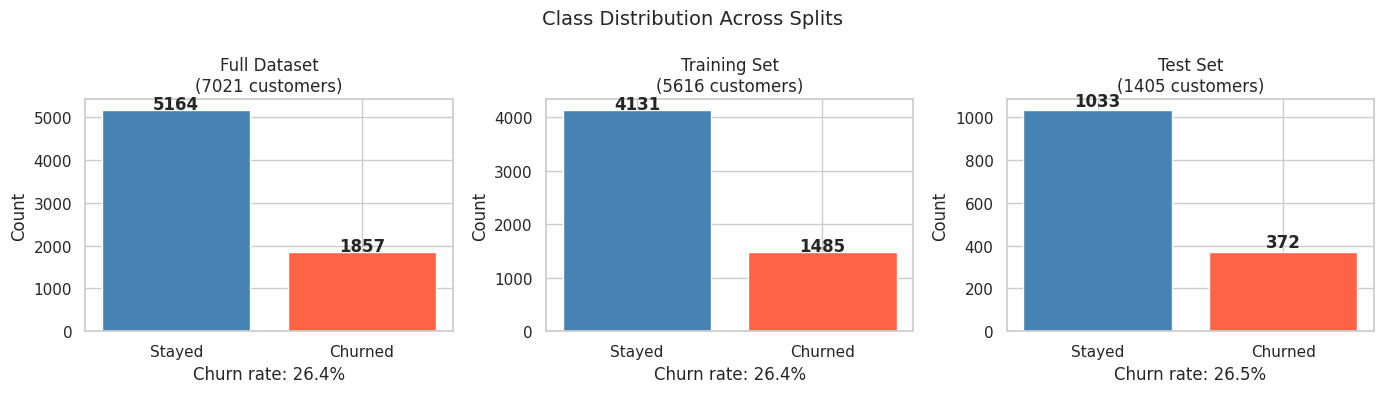

In [6]:

# =============================================================================
# CELL 7: TRAIN TEST SPLIT
# We separate features from the target then split into training
# and test sets.
#
# Two important decisions here:
#
# Stratified split — ensures both sets have the same churn rate
# as the full dataset. Critical for imbalanced datasets because
# a random split might put most churners in one set.
#
# Test set is locked away — we never touch it during training,
# feature engineering or hyperparameter tuning. It only gets
# used once at the very end for final evaluation.
# =============================================================================

# Separate features and target
X = df_engineered.drop(columns=['Churn'])
y = df_engineered['Churn']

# Stratified train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y
)

print(f"Full dataset : {X.shape[0]} customers")
print(f"Training set : {X_train.shape[0]} customers")
print(f"Test set     : {X_test.shape[0]} customers")

print(f"\nChurn rate comparison:")
print(f"  Full dataset : {y.mean():.2%}")
print(f"  Training set : {y_train.mean():.2%}")
print(f"  Test set     : {y_test.mean():.2%}")

# Visualise the split
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, data, title in zip(
    axes,
    [y, y_train, y_test],
    ['Full Dataset', 'Training Set', 'Test Set']
):
    counts = data.value_counts()
    ax.bar(
        ['Stayed', 'Churned'],
        counts.values,
        color=['steelblue', 'tomato']
    )
    ax.set_title(f'{title}\n({len(data)} customers)')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 20, str(v), ha='center', fontweight='bold')
    churn_rate = data.mean() * 100
    ax.set_xlabel(f'Churn rate: {churn_rate:.1f}%')

plt.suptitle('Class Distribution Across Splits', fontsize=14)
plt.tight_layout()
plt.show()

X_train_processed shape : (5616, 40)
X_test_processed shape  : (1405, 40)

Training churn rate before processing : 26.44%
Test churn rate before processing     : 26.48%


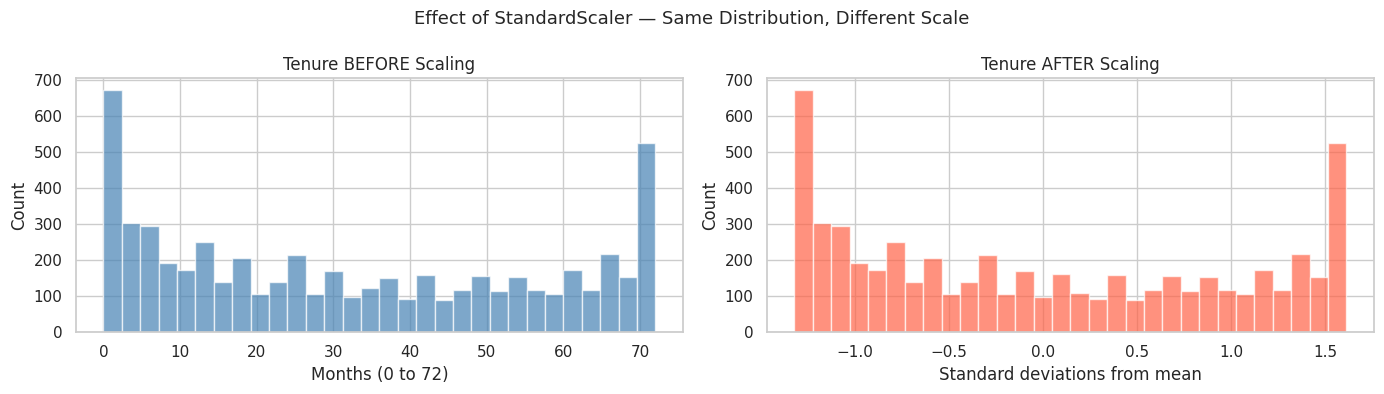


StandardScaler verification on tenure:
  Before — mean: 32.43, std: 24.52
  After  — mean: 0.0000, std: 1.0000

  After scaling mean is ~0 and std is ~1 as expected


In [7]:

# =============================================================================
# CELL 8: PREPROCESSING PIPELINE
# We build a ColumnTransformer that applies different transformations
# to different column types.
#
# Numerical columns   — impute with median then scale with StandardScaler
# Binary columns      — impute with most frequent then OrdinalEncoder
# Multiclass columns  — impute with most frequent then OneHotEncoder
#
# The pipeline is fitted on training data only then used to transform
# both training and test sets. This is the critical step that prevents
# data leakage — the scaler and encoder never see test data during fitting.
# =============================================================================

# Define column groups
NUMERICAL_COLUMNS = [
    'tenure', 'MonthlyCharges', 'TotalCharges',
    'TotalServices', 'SpendPerService', 'ChargesRatio',
    'ContractRiskScore', 'TenureContractInteraction'
]

BINARY_COLUMNS = [
    'gender', 'Partner', 'Dependents', 'PhoneService',
    'PaperlessBilling', 'HasPremiumServices', 'IsAutomatedPayment',
    'SeniorCitizen'
]

MULTICLASS_COLUMNS = [
    'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract',
    'PaymentMethod', 'TenureGroup'
]

# Build individual pipelines for each column type
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

binary_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

multiclass_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        drop='first',
        handle_unknown='ignore',
        sparse_output=False
    ))
])

# Combine into one ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('numerical',  numerical_pipeline,  NUMERICAL_COLUMNS),
        ('binary',     binary_pipeline,     BINARY_COLUMNS),
        ('multiclass', multiclass_pipeline, MULTICLASS_COLUMNS)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

# Build full pipeline including feature engineering
full_pipeline = Pipeline(steps=[
    ('feature_engineering', FeatureEngineeringTransformer()),
    ('preprocessor',        preprocessor)
])

# Fit on training data only — transform both sets
X_train_processed = full_pipeline.fit_transform(X_train)
X_test_processed  = full_pipeline.transform(X_test)

print(f"X_train_processed shape : {X_train_processed.shape}")
print(f"X_test_processed shape  : {X_test_processed.shape}")

print(f"\nTraining churn rate before processing : {y_train.mean():.2%}")
print(f"Test churn rate before processing     : {y_test.mean():.2%}")

# Visualise what StandardScaler did to numerical features
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Before scaling — raw tenure values
axes[0].hist(X_train['tenure'], bins=30, color='steelblue', alpha=0.7)
axes[0].set_title('Tenure BEFORE Scaling')
axes[0].set_xlabel('Months (0 to 72)')
axes[0].set_ylabel('Count')

# After scaling — scaled tenure values (first column in processed array)
axes[1].hist(X_train_processed[:, 0], bins=30, color='tomato', alpha=0.7)
axes[1].set_title('Tenure AFTER Scaling')
axes[1].set_xlabel('Standard deviations from mean')
axes[1].set_ylabel('Count')

plt.suptitle(
    'Effect of StandardScaler — Same Distribution, Different Scale',
    fontsize=13
)
plt.tight_layout()
plt.show()

print("\nStandardScaler verification on tenure:")
print(f"  Before — mean: {X_train['tenure'].mean():.2f}, std: {X_train['tenure'].std():.2f}")
print(f"  After  — mean: {X_train_processed[:, 0].mean():.4f}, std: {X_train_processed[:, 0].std():.4f}")
print(f"\n  After scaling mean is ~0 and std is ~1 as expected")

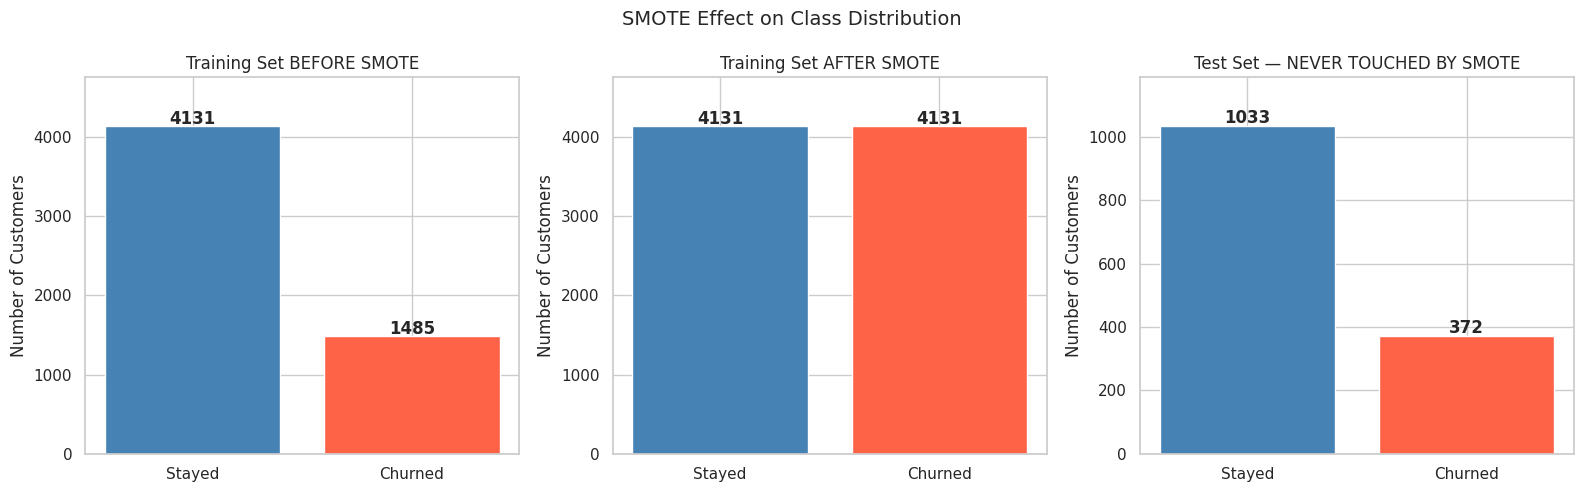

BEFORE SMOTE:
  Stayed  : 4131  (73.6%)
  Churned : 1485  (26.4%)
  Total   : 5616

AFTER SMOTE:
  Stayed  : 4131  (50.0%)
  Churned : 4131  (50.0%)
  Total   : 8262
  Synthetic customers added: 2646

TEST SET (untouched):
  Stayed  : 1033  (73.5%)
  Churned : 372  (26.5%)

HOW SMOTE CREATES SYNTHETIC CUSTOMERS

Real churners in training    : 1485
Synthetic churners created   : 2646


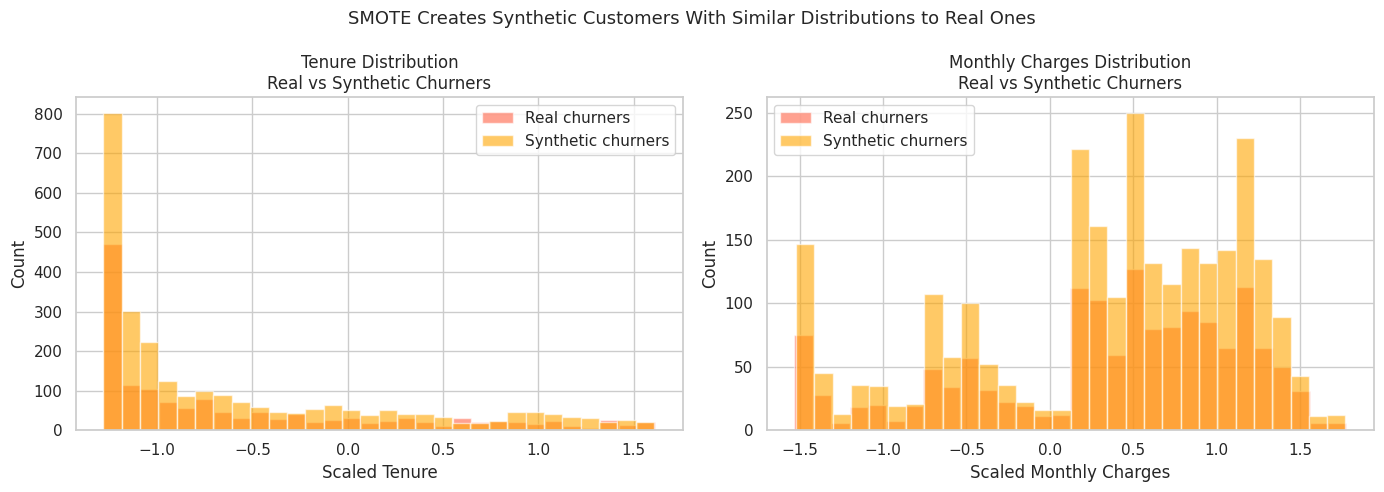


WHAT HAPPENS WITHOUT SMOTE — THE ACCURACY PARADOX

Metric                      Without SMOTE      With SMOTE
-------------------------------------------------------
Overall Accuracy                   80.71%          74.88%
Churn Precision                    67.47%          51.75%
Churn Recall                       52.42%          75.54%
Churn F1                           59.00%          61.42%

Without SMOTE the model has higher overall accuracy but
misses far more churners. That is the accuracy paradox.
High accuracy on a useless model.

With SMOTE overall accuracy drops slightly but churn recall
improves significantly — the model catches more churners.
That is what the business actually needs.


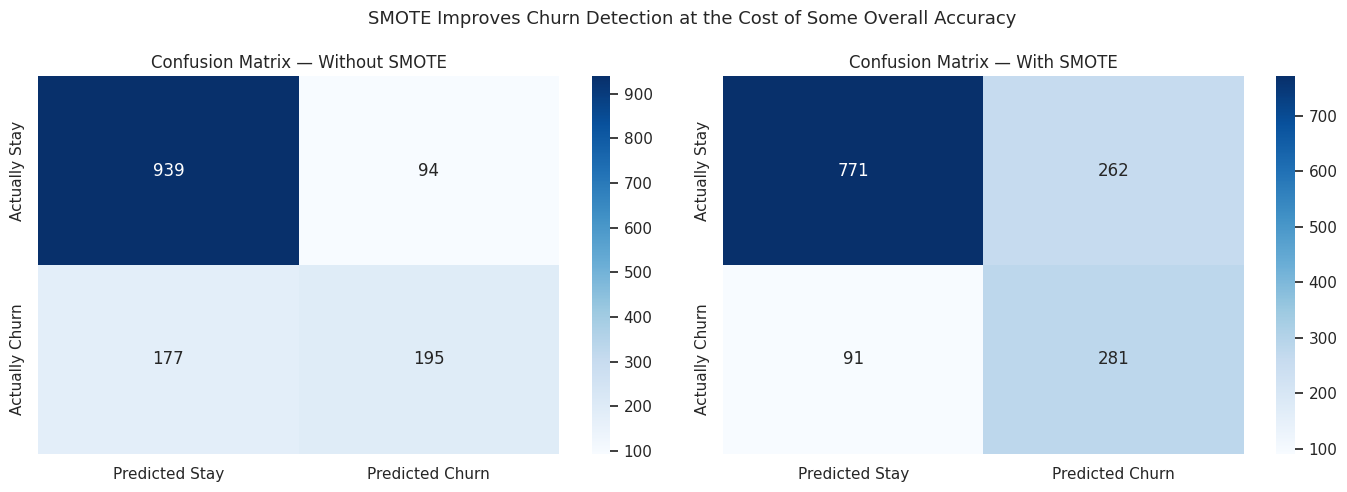

In [8]:

# =============================================================================
# CELL 9: SMOTE — SYNTHETIC MINORITY OVERSAMPLING TECHNIQUE
#
# The problem: 73.5% stayed, 26.5% churned. A naive model learns to
# always predict stayed and gets 73.5% accuracy while being completely
# useless at identifying churners.
#
# The solution: SMOTE creates synthetic churner customers by interpolating
# between real churners and their nearest neighbours. The model then
# trains on a balanced dataset and learns to genuinely distinguish
# between churners and non churners.
#
# The golden rule: SMOTE only ever touches training data.
# Validation and test sets must contain only real customers.
# =============================================================================

# ------------------------------------------------------------------
# PART 1: Visualise the imbalance problem
# ------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Before SMOTE
stayed_count  = (y_train == 0).sum()
churned_count = (y_train == 1).sum()

axes[0].bar(
    ['Stayed', 'Churned'],
    [stayed_count, churned_count],
    color=['steelblue', 'tomato']
)
axes[0].set_title('Training Set BEFORE SMOTE', fontsize=12)
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate([stayed_count, churned_count]):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')
axes[0].set_ylim(0, max(stayed_count, churned_count) * 1.15)

# Apply SMOTE
smote = SMOTE(
    sampling_strategy='auto',
    k_neighbors=5,
    random_state=RANDOM_SEED
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed, y_train
)

# After SMOTE
stayed_after  = (y_train_smote == 0).sum()
churned_after = (y_train_smote == 1).sum()

axes[1].bar(
    ['Stayed', 'Churned'],
    [stayed_after, churned_after],
    color=['steelblue', 'tomato']
)
axes[1].set_title('Training Set AFTER SMOTE', fontsize=12)
axes[1].set_ylabel('Number of Customers')
for i, v in enumerate([stayed_after, churned_after]):
    axes[1].text(i, v + 30, str(v), ha='center', fontweight='bold')
axes[1].set_ylim(0, max(stayed_after, churned_after) * 1.15)

# Test set untouched
stayed_test  = (y_test == 0).sum()
churned_test = (y_test == 1).sum()

axes[2].bar(
    ['Stayed', 'Churned'],
    [stayed_test, churned_test],
    color=['steelblue', 'tomato']
)
axes[2].set_title('Test Set — NEVER TOUCHED BY SMOTE', fontsize=12)
axes[2].set_ylabel('Number of Customers')
for i, v in enumerate([stayed_test, churned_test]):
    axes[2].text(i, v + 10, str(v), ha='center', fontweight='bold')
axes[2].set_ylim(0, max(stayed_test, churned_test) * 1.15)

plt.suptitle('SMOTE Effect on Class Distribution', fontsize=14)
plt.tight_layout()
plt.show()

print(f"BEFORE SMOTE:")
print(f"  Stayed  : {stayed_count}  ({stayed_count/len(y_train):.1%})")
print(f"  Churned : {churned_count}  ({churned_count/len(y_train):.1%})")
print(f"  Total   : {len(y_train)}")

print(f"\nAFTER SMOTE:")
print(f"  Stayed  : {stayed_after}  ({stayed_after/len(y_train_smote):.1%})")
print(f"  Churned : {churned_after}  ({churned_after/len(y_train_smote):.1%})")
print(f"  Total   : {len(y_train_smote)}")
print(f"  Synthetic customers added: {churned_after - churned_count}")

print(f"\nTEST SET (untouched):")
print(f"  Stayed  : {stayed_test}  ({stayed_test/len(y_test):.1%})")
print(f"  Churned : {churned_test}  ({churned_test/len(y_test):.1%})")

# ------------------------------------------------------------------
# PART 2: Show exactly how SMOTE creates synthetic customers
# ------------------------------------------------------------------

print(f"\n{'=' * 60}")
print("HOW SMOTE CREATES SYNTHETIC CUSTOMERS")
print("=" * 60)

# Get the real churners from training set
real_churners = X_train_processed[y_train == 1]

# The synthetic churners are everything added after the real ones
synthetic_churners = X_train_smote[
    len(X_train_processed):
]

print(f"\nReal churners in training    : {len(real_churners)}")
print(f"Synthetic churners created   : {len(synthetic_churners)}")

# Compare real vs synthetic on the first two numerical features
# tenure (column 0) and MonthlyCharges (column 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tenure distribution — real vs synthetic churners
axes[0].hist(
    real_churners[:, 0],
    bins=30, alpha=0.6,
    color='tomato', label='Real churners'
)
axes[0].hist(
    synthetic_churners[:, 0],
    bins=30, alpha=0.6,
    color='orange', label='Synthetic churners'
)
axes[0].set_title('Tenure Distribution\nReal vs Synthetic Churners')
axes[0].set_xlabel('Scaled Tenure')
axes[0].set_ylabel('Count')
axes[0].legend()

# Monthly charges distribution — real vs synthetic churners
axes[1].hist(
    real_churners[:, 1],
    bins=30, alpha=0.6,
    color='tomato', label='Real churners'
)
axes[1].hist(
    synthetic_churners[:, 1],
    bins=30, alpha=0.6,
    color='orange', label='Synthetic churners'
)
axes[1].set_title('Monthly Charges Distribution\nReal vs Synthetic Churners')
axes[1].set_xlabel('Scaled Monthly Charges')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle(
    'SMOTE Creates Synthetic Customers With Similar Distributions to Real Ones',
    fontsize=13
)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# PART 3: Show what happens without SMOTE
# ------------------------------------------------------------------

print(f"\n{'=' * 60}")
print("WHAT HAPPENS WITHOUT SMOTE — THE ACCURACY PARADOX")
print("=" * 60)

# Train a model without SMOTE
no_smote_model = LogisticRegression(
    random_state=RANDOM_SEED,
    max_iter=3000
)
no_smote_model.fit(X_train_processed, y_train)
no_smote_pred = no_smote_model.predict(X_test_processed)

# Train a model with SMOTE
smote_model = LogisticRegression(
    random_state=RANDOM_SEED,
    max_iter=3000
)
smote_model.fit(X_train_smote, y_train_smote)
smote_pred = smote_model.predict(X_test_processed)

# Compare
from sklearn.metrics import accuracy_score

print(f"\n{'Metric':<25} {'Without SMOTE':>15} {'With SMOTE':>15}")
print("-" * 55)
print(f"{'Overall Accuracy':<25} {accuracy_score(y_test, no_smote_pred):>15.2%} {accuracy_score(y_test, smote_pred):>15.2%}")

no_smote_report = classification_report(y_test, no_smote_pred, output_dict=True)
smote_report    = classification_report(y_test, smote_pred,    output_dict=True)

print(f"{'Churn Precision':<25} {no_smote_report['1']['precision']:>15.2%} {smote_report['1']['precision']:>15.2%}")
print(f"{'Churn Recall':<25} {no_smote_report['1']['recall']:>15.2%} {smote_report['1']['recall']:>15.2%}")
print(f"{'Churn F1':<25} {no_smote_report['1']['f1-score']:>15.2%} {smote_report['1']['f1-score']:>15.2%}")

print(f"\nWithout SMOTE the model has higher overall accuracy but")
print(f"misses far more churners. That is the accuracy paradox.")
print(f"High accuracy on a useless model.")
print(f"\nWith SMOTE overall accuracy drops slightly but churn recall")
print(f"improves significantly — the model catches more churners.")
print(f"That is what the business actually needs.")

# Visualise the comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, title in zip(
    axes,
    [no_smote_pred, smote_pred],
    ['Without SMOTE', 'With SMOTE']
):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Predicted Stay', 'Predicted Churn'],
        yticklabels=['Actually Stay', 'Actually Churn'],
        ax=ax
    )
    ax.set_title(f'Confusion Matrix — {title}', fontsize=12)

plt.suptitle(
    'SMOTE Improves Churn Detection at the Cost of Some Overall Accuracy',
    fontsize=13
)
plt.tight_layout()
plt.show()

Starting GridSearchCV...
Total combinations : 24 parameter combinations
Total fits         : 120 (combinations x folds)
This will take a few minutes...

Fitting 5 folds for each of 24 candidates, totalling 120 fits

GRIDSEARCHCV RESULTS
Best parameters:
  C          : 1
  penalty    : l1
  solver     : saga

Best ROC AUC (cross validation) : 0.8470

Top 5 hyperparameter combinations:
C        Penalty  Solver       Val AUC      Train AUC    Gap
------------------------------------------------------------
1.0      l1       saga         0.8470       0.8520       0.0050
1.0      l1       liblinear    0.8470       0.8520       0.0050
1.0      l2       liblinear    0.8470       0.8520       0.0051
1.0      l2       saga         0.8470       0.8520       0.0050
0.1      l2       saga         0.8469       0.8517       0.0048

Overfitting check:
  Train ROC AUC      : 0.8520
  Validation ROC AUC : 0.8470
  Gap                : 0.0050
  No significant overfitting detected


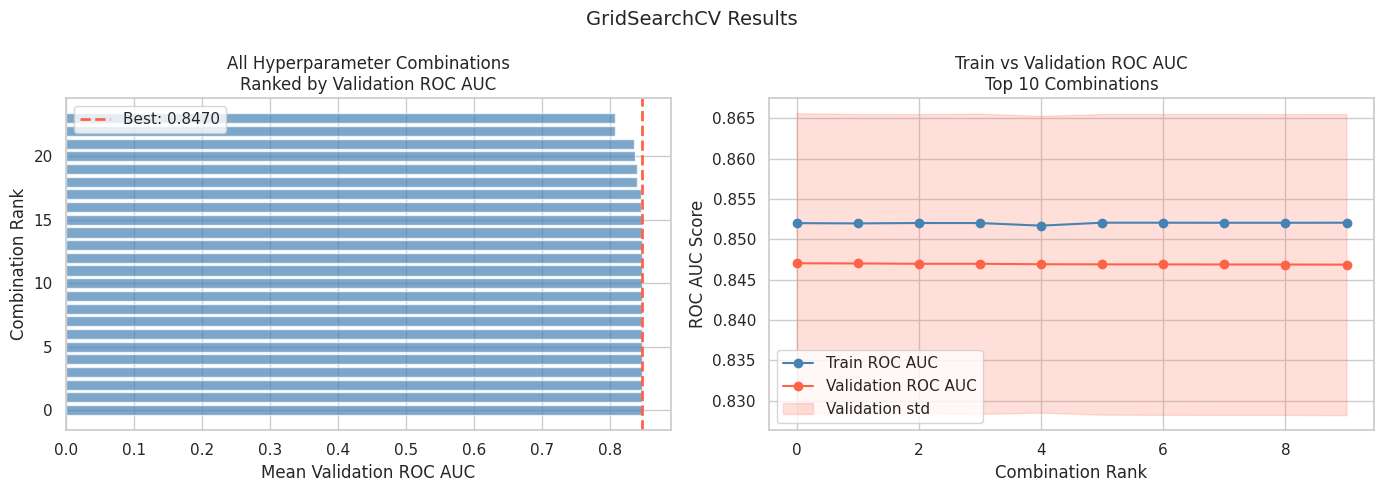

In [9]:

# =============================================================================
# CELL 10: TRAINING WITH GRIDSEARCHCV
#
# We use an imblearn Pipeline that combines SMOTE and LogisticRegression.
# The key reason for using imblearn Pipeline instead of sklearn Pipeline
# is that imblearn Pipeline correctly applies SMOTE only on training
# folds during cross validation and skips it on validation folds.
#
# This is the correct way to combine SMOTE with cross validation.
# Applying SMOTE before cross validation would leak synthetic customers
# into validation folds giving falsely optimistic metrics.
#
# GridSearchCV tries every combination of hyperparameters and picks
# the one with the highest average ROC AUC across all 5 folds.
# =============================================================================

# Build the model pipeline
# SMOTE goes inside the pipeline so it is applied correctly per fold
model_pipeline = ImbPipeline(steps=[
    (
        'smote',
        SMOTE(
            sampling_strategy='auto',
            k_neighbors=5,
            random_state=RANDOM_SEED
        )
    ),
    (
        'logisticregression',
        LogisticRegression(
            class_weight='balanced',
            max_iter=3000,
            random_state=RANDOM_SEED
        )
    )
])

# Hyperparameter grid
# C is the inverse of regularization strength
# Small C = strong regularization = simpler model
# Large C = weak regularization = more complex model
param_grid = {
    'logisticregression__C'      : [0.001, 0.01, 0.1, 1, 10, 100],
    'logisticregression__penalty': ['l1', 'l2'],
    'logisticregression__solver' : ['liblinear', 'saga']
}

# Stratified K-Fold cross validator
# Stratified ensures each fold has the same churn rate as the full set
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_SEED
)

# GridSearchCV
grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    refit=True,
    return_train_score=True
)

print("Starting GridSearchCV...")
print(f"Total combinations : {6 * 2 * 2} parameter combinations")
print(f"Total fits         : {6 * 2 * 2 * 5} (combinations x folds)")
print(f"This will take a few minutes...\n")

grid_search.fit(X_train_processed, y_train)

# Extract best model
best_model = grid_search.best_estimator_

print(f"\n{'=' * 60}")
print(f"GRIDSEARCHCV RESULTS")
print(f"{'=' * 60}")
print(f"Best parameters:")
for param, value in grid_search.best_params_.items():
    clean_param = param.replace('logisticregression__', '')
    print(f"  {clean_param:<10} : {value}")
print(f"\nBest ROC AUC (cross validation) : {grid_search.best_score_:.4f}")

# Show top 5 combinations
results = pd.DataFrame(grid_search.cv_results_)
results = results.sort_values('mean_test_score', ascending=False)

print(f"\nTop 5 hyperparameter combinations:")
print(f"{'C':<8} {'Penalty':<8} {'Solver':<12} {'Val AUC':<12} {'Train AUC':<12} {'Gap'}")
print("-" * 60)

for _, row in results.head(5).iterrows():
    c       = row['param_logisticregression__C']
    penalty = row['param_logisticregression__penalty']
    solver  = row['param_logisticregression__solver']
    val     = row['mean_test_score']
    train   = row['mean_train_score']
    gap     = train - val
    print(f"{str(c):<8} {str(penalty):<8} {str(solver):<12} {val:<12.4f} {train:<12.4f} {gap:.4f}")

# Overfitting check
best_row   = results.iloc[0]
train_score = best_row['mean_train_score']
val_score   = best_row['mean_test_score']
gap         = train_score - val_score

print(f"\nOverfitting check:")
print(f"  Train ROC AUC      : {train_score:.4f}")
print(f"  Validation ROC AUC : {val_score:.4f}")
print(f"  Gap                : {gap:.4f}")

if gap > 0.05:
    print(f"  Warning — potential overfitting detected")
else:
    print(f"  No significant overfitting detected")

# Visualise cross validation results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot all combinations ranked by validation score
valid_results = results.dropna(subset=['mean_test_score'])
axes[0].barh(
    range(len(valid_results)),
    valid_results['mean_test_score'].values,
    color='steelblue',
    alpha=0.7
)
axes[0].axvline(
    x=grid_search.best_score_,
    color='tomato',
    linestyle='--',
    linewidth=2,
    label=f'Best: {grid_search.best_score_:.4f}'
)
axes[0].set_title('All Hyperparameter Combinations\nRanked by Validation ROC AUC')
axes[0].set_xlabel('Mean Validation ROC AUC')
axes[0].set_ylabel('Combination Rank')
axes[0].legend()

# Plot train vs validation scores for top 10
top10 = valid_results.head(10)
x = range(len(top10))
axes[1].plot(x, top10['mean_train_score'].values, 'o-',
             color='steelblue', label='Train ROC AUC')
axes[1].plot(x, top10['mean_test_score'].values, 'o-',
             color='tomato', label='Validation ROC AUC')
axes[1].fill_between(
    x,
    top10['mean_test_score'].values - top10['std_test_score'].values,
    top10['mean_test_score'].values + top10['std_test_score'].values,
    alpha=0.2, color='tomato', label='Validation std'
)
axes[1].set_title('Train vs Validation ROC AUC\nTop 10 Combinations')
axes[1].set_xlabel('Combination Rank')
axes[1].set_ylabel('ROC AUC Score')
axes[1].legend()

plt.suptitle('GridSearchCV Results', fontsize=14)
plt.tight_layout()
plt.show()

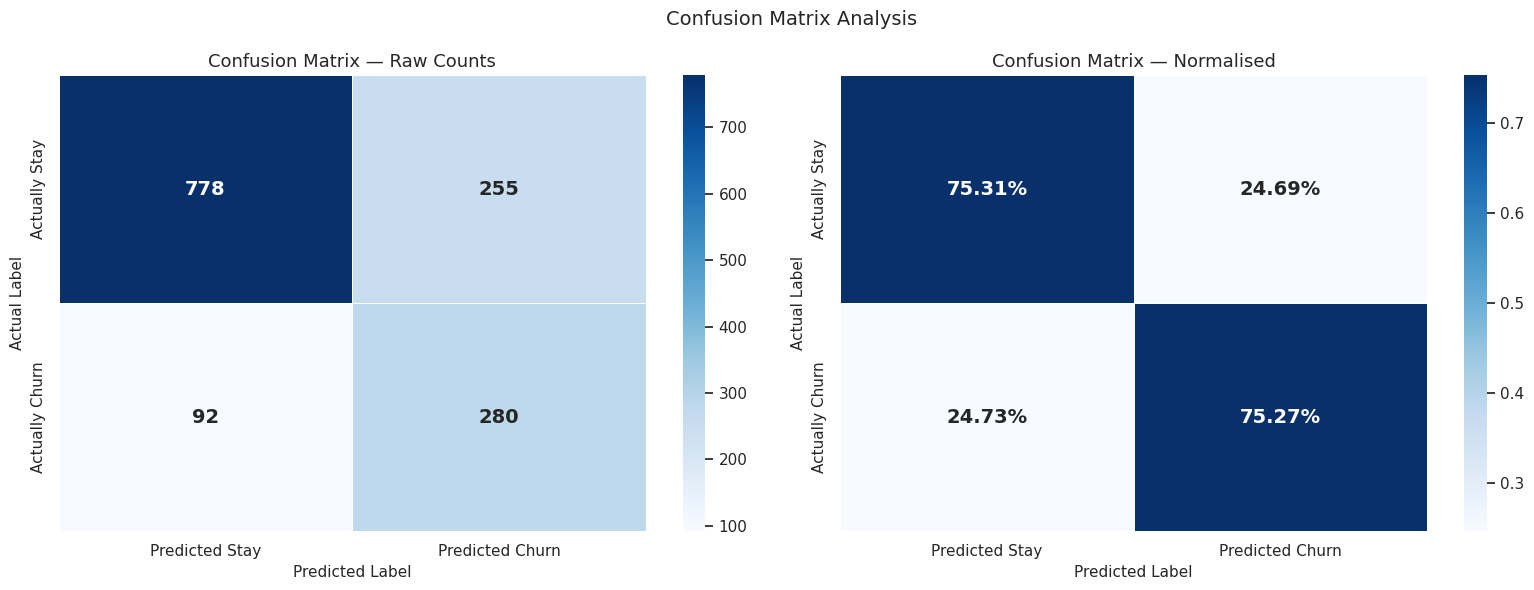

CONFUSION MATRIX — BUSINESS INTERPRETATION

True Negatives  (TN) = 778
  Loyal customers correctly identified as staying
  No action needed — model got it right

False Positives (FP) = 255
  Loyal customers incorrectly flagged as churners
  Retention offer sent unnecessarily
  Cost: wasted retention budget

False Negatives (FN) = 92
  Churners the model completely missed
  These customers left without any intervention
  Cost: lost customer lifetime value — most expensive mistake

True Positives  (TP) = 280
  Churners correctly identified before they left
  Retention team can intervene
  This is what the model exists to do

Of 372 actual churners in the test set:
  Model caught  : 280 (75.3%)
  Model missed  : 92 (24.7%)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Stayed (0)       0.89      0.75      0.82      1033
 Churned (1)       0.52      0.75      0.62       372

    accuracy                           0.75      1405
   macro avg       0.71      

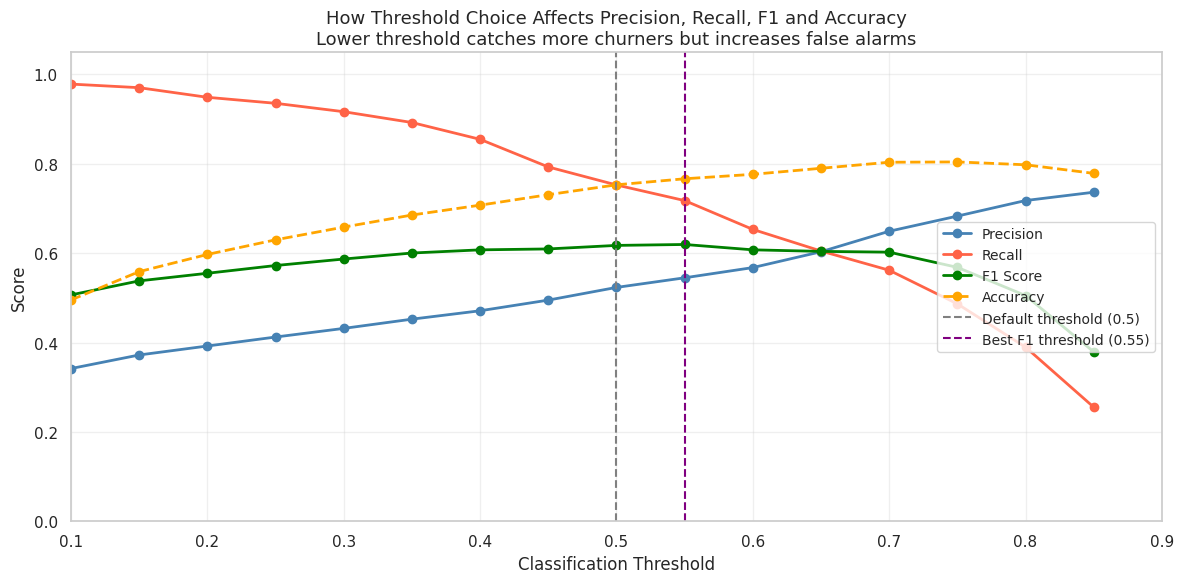


Threshold Analysis:
  Default threshold (0.5):
    Precision : 0.5234
    Recall    : 0.7527
    F1 Score  : 0.6174

  Best F1 threshold (0.55):
    Precision : 0.5449
    Recall    : 0.7177
    F1 Score  : 0.6195

Business decision:
  If missing a churner costs more than a wasted offer
  lower the threshold to increase recall
  If the retention budget is tight
  raise the threshold to increase precision


In [10]:

# =============================================================================
# CELL 11: EVALUATION — CONFUSION MATRIX AND CLASSIFICATION REPORT
#
# We evaluate the model on the test set which has never been seen
# during training or hyperparameter tuning.
#
# Two types of predictions:
# predict()       — binary class prediction using threshold 0.5
# predict_proba() — probability of churn for each customer
#                   used for ROC AUC and threshold analysis
# =============================================================================

# Generate predictions on test set
y_pred = best_model.predict(X_test_processed)
y_prob = best_model.predict_proba(X_test_processed)[:, 1]

# ------------------------------------------------------------------
# PART 1: Confusion Matrix
# ------------------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts confusion matrix
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted Stay', 'Predicted Churn'],
    yticklabels=['Actually Stay', 'Actually Churn'],
    ax=axes[0],
    linewidths=0.5,
    annot_kws={'size': 14, 'weight': 'bold'}
)
axes[0].set_title('Confusion Matrix — Raw Counts', fontsize=13)
axes[0].set_ylabel('Actual Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)

# Normalised confusion matrix — shows percentages
cm_normalised = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(
    cm_normalised,
    annot=True,
    fmt='.2%',
    cmap='Blues',
    xticklabels=['Predicted Stay', 'Predicted Churn'],
    yticklabels=['Actually Stay', 'Actually Churn'],
    ax=axes[1],
    linewidths=0.5,
    annot_kws={'size': 14, 'weight': 'bold'}
)
axes[1].set_title('Confusion Matrix — Normalised', fontsize=13)
axes[1].set_ylabel('Actual Label', fontsize=11)
axes[1].set_xlabel('Predicted Label', fontsize=11)

plt.suptitle('Confusion Matrix Analysis', fontsize=14)
plt.tight_layout()
plt.show()

# Business interpretation
print(f"CONFUSION MATRIX — BUSINESS INTERPRETATION")
print(f"{'=' * 60}")
print(f"\nTrue Negatives  (TN) = {tn}")
print(f"  Loyal customers correctly identified as staying")
print(f"  No action needed — model got it right")

print(f"\nFalse Positives (FP) = {fp}")
print(f"  Loyal customers incorrectly flagged as churners")
print(f"  Retention offer sent unnecessarily")
print(f"  Cost: wasted retention budget")

print(f"\nFalse Negatives (FN) = {fn}")
print(f"  Churners the model completely missed")
print(f"  These customers left without any intervention")
print(f"  Cost: lost customer lifetime value — most expensive mistake")

print(f"\nTrue Positives  (TP) = {tp}")
print(f"  Churners correctly identified before they left")
print(f"  Retention team can intervene")
print(f"  This is what the model exists to do")

print(f"\n{'=' * 60}")
print(f"Of {tp + fn} actual churners in the test set:")
print(f"  Model caught  : {tp} ({tp/(tp+fn):.1%})")
print(f"  Model missed  : {fn} ({fn/(tp+fn):.1%})")

# ------------------------------------------------------------------
# PART 2: Classification Report
# ------------------------------------------------------------------

print(f"\n{'=' * 60}")
print(f"CLASSIFICATION REPORT")
print(f"{'=' * 60}")
print(classification_report(
    y_test, y_pred,
    target_names=['Stayed (0)', 'Churned (1)']
))

# ------------------------------------------------------------------
# PART 3: Threshold Analysis
# ------------------------------------------------------------------
# Default threshold is 0.5 but the business might prefer a different
# threshold depending on whether they care more about recall or precision.
# Lower threshold = catch more churners but more false alarms
# Higher threshold = fewer false alarms but miss more churners

thresholds   = np.arange(0.1, 0.9, 0.05)
precisions   = []
recalls      = []
f1_scores    = []
accuracies   = []

for threshold in thresholds:
    y_pred_thresh = (y_prob >= threshold).astype(int)
    report = classification_report(
        y_test, y_pred_thresh,
        output_dict=True,
        zero_division=0
    )
    precisions.append(report['1']['precision'])
    recalls.append(report['1']['recall'])
    f1_scores.append(report['1']['f1-score'])
    accuracies.append(report['accuracy'])

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(thresholds, precisions, 'o-', color='steelblue',
        linewidth=2, label='Precision')
ax.plot(thresholds, recalls,    'o-', color='tomato',
        linewidth=2, label='Recall')
ax.plot(thresholds, f1_scores,  'o-', color='green',
        linewidth=2, label='F1 Score')
ax.plot(thresholds, accuracies, 'o-', color='orange',
        linewidth=2, label='Accuracy', linestyle='--')

ax.axvline(x=0.5, color='gray', linestyle='--',
           linewidth=1.5, label='Default threshold (0.5)')

# Find threshold that maximises F1
best_threshold_idx = np.argmax(f1_scores)
best_threshold     = thresholds[best_threshold_idx]
best_f1            = f1_scores[best_threshold_idx]

ax.axvline(x=best_threshold, color='purple', linestyle='--',
           linewidth=1.5, label=f'Best F1 threshold ({best_threshold:.2f})')

ax.set_xlabel('Classification Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(
    'How Threshold Choice Affects Precision, Recall, F1 and Accuracy\n'
    'Lower threshold catches more churners but increases false alarms',
    fontsize=13
)
ax.legend(loc='center right', fontsize=10)
ax.set_xlim([0.1, 0.9])
ax.set_ylim([0.0, 1.05])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nThreshold Analysis:")
print(f"  Default threshold (0.5):")
default_idx = np.argmin(np.abs(thresholds - 0.5))
print(f"    Precision : {precisions[default_idx]:.4f}")
print(f"    Recall    : {recalls[default_idx]:.4f}")
print(f"    F1 Score  : {f1_scores[default_idx]:.4f}")

print(f"\n  Best F1 threshold ({best_threshold:.2f}):")
print(f"    Precision : {precisions[best_threshold_idx]:.4f}")
print(f"    Recall    : {recalls[best_threshold_idx]:.4f}")
print(f"    F1 Score  : {best_f1:.4f}")

print(f"\nBusiness decision:")
print(f"  If missing a churner costs more than a wasted offer")
print(f"  lower the threshold to increase recall")
print(f"  If the retention budget is tight")
print(f"  raise the threshold to increase precision")

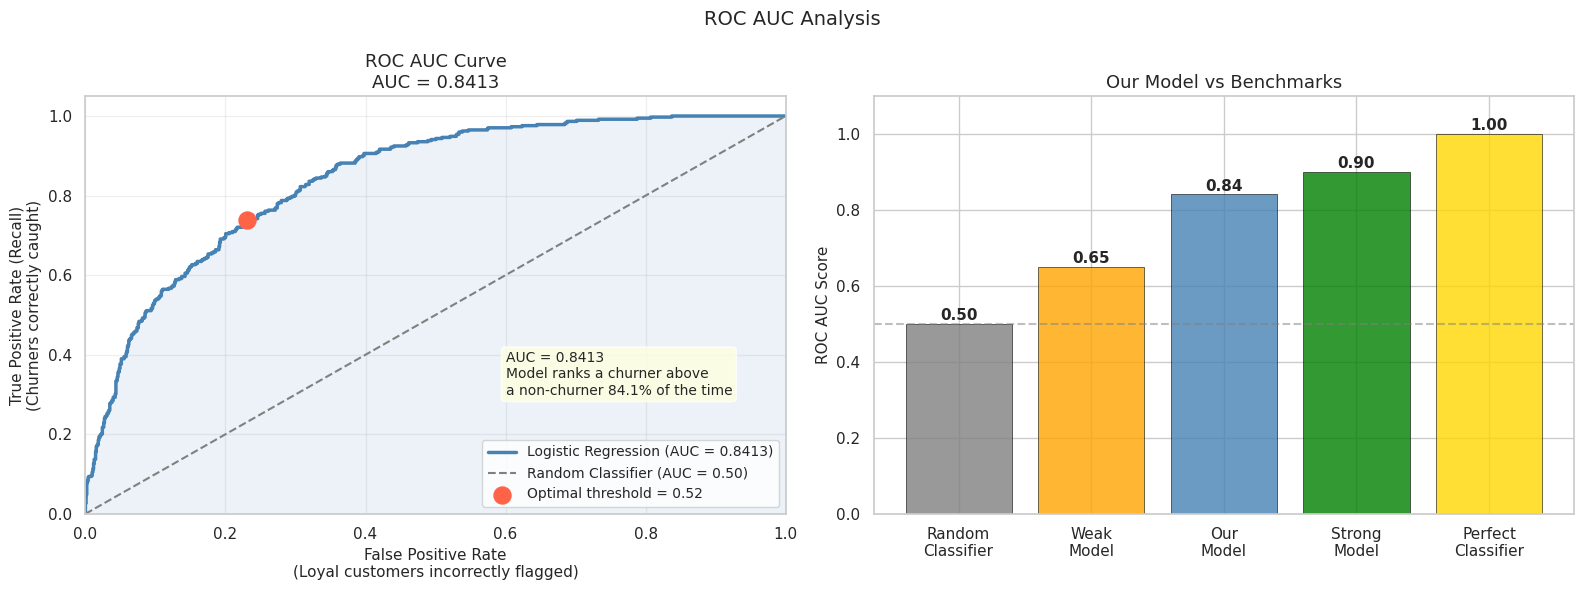

ROC AUC Score    : 0.8413
Optimal threshold: 0.5246
  At this threshold:
  True Positive Rate  : 73.92% of churners caught
  False Positive Rate : 23.14% of loyal customers wrongly flagged


In [11]:

# =============================================================================
# CELL 12: ROC AUC CURVE
#
# The ROC curve plots True Positive Rate (recall) against False Positive
# Rate across every possible classification threshold from 0 to 1.
#
# True Positive Rate  = TP / (TP + FN) — what fraction of churners we catch
# False Positive Rate = FP / (FP + TN) — what fraction of loyal customers
#                                         we incorrectly flag
#
# A perfect model hugs the top left corner — high recall with zero
# false positives. A random model follows the diagonal line.
#
# The AUC (Area Under the Curve) summarises the entire curve as one number.
# AUC = 0.5 means random guessing
# AUC = 1.0 means perfect classification
# AUC = 0.84 means our model correctly ranks a churner above a
#             non churner 84% of the time
# =============================================================================

fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

# Find the optimal threshold — point closest to top left corner
# This maximises TPR while minimising FPR
distances        = np.sqrt((fpr - 0) ** 2 + (tpr - 1) ** 2)
optimal_idx      = np.argmin(distances)
optimal_threshold = thresholds_roc[optimal_idx]
optimal_fpr      = fpr[optimal_idx]
optimal_tpr      = tpr[optimal_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ------------------------------------------------------------------
# Plot 1: ROC Curve
# ------------------------------------------------------------------
axes[0].plot(
    fpr, tpr,
    color='steelblue',
    linewidth=2.5,
    label=f'Logistic Regression (AUC = {auc_score:.4f})'
)

# Random classifier baseline
axes[0].plot(
    [0, 1], [0, 1],
    color='gray',
    linewidth=1.5,
    linestyle='--',
    label='Random Classifier (AUC = 0.50)'
)

# Mark optimal threshold point
axes[0].scatter(
    optimal_fpr, optimal_tpr,
    color='tomato',
    s=150,
    zorder=5,
    label=f'Optimal threshold = {optimal_threshold:.2f}'
)

# Shade the area under the curve
axes[0].fill_between(fpr, tpr, alpha=0.1, color='steelblue')

axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate\n(Loyal customers incorrectly flagged)', fontsize=11)
axes[0].set_ylabel('True Positive Rate (Recall)\n(Churners correctly caught)', fontsize=11)
axes[0].set_title(f'ROC AUC Curve\nAUC = {auc_score:.4f}', fontsize=13)
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(True, alpha=0.3)

# Add annotation explaining AUC
axes[0].annotate(
    f'AUC = {auc_score:.4f}\n'
    f'Model ranks a churner above\n'
    f'a non-churner {auc_score:.1%} of the time',
    xy=(0.6, 0.3),
    fontsize=10,
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)

# ------------------------------------------------------------------
# Plot 2: AUC Score in Context
# Compares our model against benchmarks
# ------------------------------------------------------------------
benchmarks = {
    'Random\nClassifier'  : 0.50,
    'Weak\nModel'         : 0.65,
    'Our\nModel'          : auc_score,
    'Strong\nModel'       : 0.90,
    'Perfect\nClassifier' : 1.00
}

colors = ['gray', 'orange', 'steelblue', 'green', 'gold']
bars   = axes[1].bar(
    benchmarks.keys(),
    benchmarks.values(),
    color=colors,
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5
)

axes[1].set_ylim([0.0, 1.1])
axes[1].set_ylabel('ROC AUC Score', fontsize=11)
axes[1].set_title('Our Model vs Benchmarks', fontsize=13)
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

for bar, value in zip(bars, benchmarks.values()):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{value:.2f}',
        ha='center',
        fontweight='bold',
        fontsize=11
    )

plt.suptitle('ROC AUC Analysis', fontsize=14)
plt.tight_layout()
plt.show()

print(f"ROC AUC Score    : {auc_score:.4f}")
print(f"Optimal threshold: {optimal_threshold:.4f}")
print(f"  At this threshold:")
print(f"  True Positive Rate  : {optimal_tpr:.2%} of churners caught")
print(f"  False Positive Rate : {optimal_fpr:.2%} of loyal customers wrongly flagged")

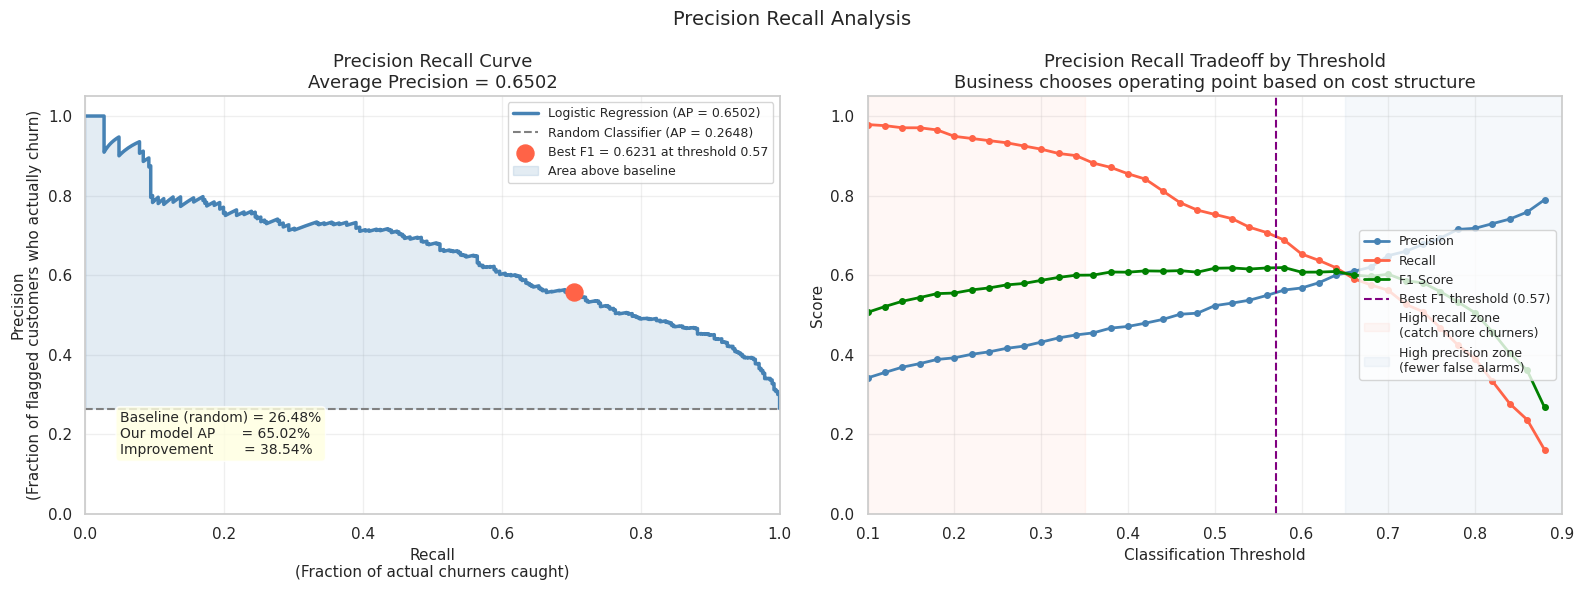

PRECISION RECALL ANALYSIS
Average Precision Score : 0.6502
Baseline (random)       : 0.2648
Improvement over random : 0.3854

Business Scenarios:

Threshold    Precision    Recall       F1           Scenario
--------------------------------------------------------------------------------
0.30         43.16%       91.67%       58.69%       Aggressive retention — catch as many churners as possible
0.50         52.34%       75.27%       61.74%       Balanced — default operating point
0.55         54.49%       71.77%       61.95%       Best F1 — optimal precision recall balance
0.70         64.91%       56.18%       60.23%       Conservative — only flag high confidence churners

Key insight:
  Threshold 0.3  catches more churners but wastes retention budget
  Threshold 0.7  saves budget but misses many churners
  Threshold 0.55 is the sweet spot for most telecom businesses


In [12]:

# =============================================================================
# CELL 13: PRECISION RECALL CURVE
#
# The Precision Recall curve is more informative than ROC AUC when
# classes are imbalanced. Here is why:
#
# ROC AUC uses True Negatives in its calculation through False Positive
# Rate. With imbalanced data there are many True Negatives so the False
# Positive Rate stays low even for a poor model. This makes ROC AUC
# look optimistic.
#
# Precision Recall ignores True Negatives completely. It only cares
# about how well the model handles the minority class — churners.
# This makes it a more honest metric for imbalanced problems.
#
# Baseline precision = churn rate in test set (26.45%)
# A random classifier would achieve exactly this baseline.
# Anything above the baseline means the model is adding value.
# =============================================================================

precision_vals, recall_vals, thresholds_pr = precision_recall_curve(
    y_test, y_prob
)
avg_precision = average_precision_score(y_test, y_prob)
baseline      = y_test.mean()

# Find threshold that maximises F1 on PR curve
f1_vals          = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-8)
best_pr_idx      = np.argmax(f1_vals)
best_pr_threshold = thresholds_pr[best_pr_idx] if best_pr_idx < len(thresholds_pr) else thresholds_pr[-1]
best_pr_precision = precision_vals[best_pr_idx]
best_pr_recall    = recall_vals[best_pr_idx]
best_pr_f1        = f1_vals[best_pr_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ------------------------------------------------------------------
# Plot 1: Precision Recall Curve
# ------------------------------------------------------------------
axes[0].plot(
    recall_vals, precision_vals,
    color='steelblue',
    linewidth=2.5,
    label=f'Logistic Regression (AP = {avg_precision:.4f})'
)

# Baseline — random classifier achieves precision = churn rate
axes[0].axhline(
    y=baseline,
    color='gray',
    linewidth=1.5,
    linestyle='--',
    label=f'Random Classifier (AP = {baseline:.4f})'
)

# Mark the point that maximises F1
axes[0].scatter(
    best_pr_recall, best_pr_precision,
    color='tomato',
    s=150,
    zorder=5,
    label=f'Best F1 = {best_pr_f1:.4f} at threshold {best_pr_threshold:.2f}'
)

# Shade area between curve and baseline
axes[0].fill_between(
    recall_vals, baseline, precision_vals,
    where=precision_vals > baseline,
    alpha=0.15, color='steelblue',
    label='Area above baseline'
)

axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel(
    'Recall\n(Fraction of actual churners caught)',
    fontsize=11
)
axes[0].set_ylabel(
    'Precision\n(Fraction of flagged customers who actually churn)',
    fontsize=11
)
axes[0].set_title(
    f'Precision Recall Curve\nAverage Precision = {avg_precision:.4f}',
    fontsize=13
)
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Add annotation
axes[0].annotate(
    f'Baseline (random) = {baseline:.2%}\n'
    f'Our model AP      = {avg_precision:.2%}\n'
    f'Improvement       = {(avg_precision - baseline):.2%}',
    xy=(0.05, 0.15),
    fontsize=10,
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)

# ------------------------------------------------------------------
# Plot 2: Precision Recall Tradeoff at Different Thresholds
# Shows the business decision more clearly
# ------------------------------------------------------------------
# Use thresholds from 0.1 to 0.9
thresh_range  = np.arange(0.1, 0.9, 0.02)
pr_precisions = []
pr_recalls    = []
pr_f1s        = []

for thresh in thresh_range:
    y_pred_t = (y_prob >= thresh).astype(int)
    if y_pred_t.sum() == 0:
        pr_precisions.append(1.0)
        pr_recalls.append(0.0)
        pr_f1s.append(0.0)
    else:
        report = classification_report(
            y_test, y_pred_t,
            output_dict=True,
            zero_division=0
        )
        pr_precisions.append(report['1']['precision'])
        pr_recalls.append(report['1']['recall'])
        pr_f1s.append(report['1']['f1-score'])

axes[1].plot(
    thresh_range, pr_precisions,
    'o-', color='steelblue',
    linewidth=2, markersize=4,
    label='Precision'
)
axes[1].plot(
    thresh_range, pr_recalls,
    'o-', color='tomato',
    linewidth=2, markersize=4,
    label='Recall'
)
axes[1].plot(
    thresh_range, pr_f1s,
    'o-', color='green',
    linewidth=2, markersize=4,
    label='F1 Score'
)

axes[1].axvline(
    x=best_pr_threshold,
    color='purple',
    linestyle='--',
    linewidth=1.5,
    label=f'Best F1 threshold ({best_pr_threshold:.2f})'
)

# Annotate business zones
axes[1].axvspan(0.1, 0.35, alpha=0.05, color='tomato',
                label='High recall zone\n(catch more churners)')
axes[1].axvspan(0.65, 0.9, alpha=0.05, color='steelblue',
                label='High precision zone\n(fewer false alarms)')

axes[1].set_xlabel('Classification Threshold', fontsize=11)
axes[1].set_ylabel('Score', fontsize=11)
axes[1].set_title(
    'Precision Recall Tradeoff by Threshold\n'
    'Business chooses operating point based on cost structure',
    fontsize=13
)
axes[1].legend(loc='center right', fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0.1, 0.9])
axes[1].set_ylim([0.0, 1.05])

plt.suptitle('Precision Recall Analysis', fontsize=14)
plt.tight_layout()
plt.show()

# Business scenarios
print(f"PRECISION RECALL ANALYSIS")
print(f"{'=' * 60}")
print(f"Average Precision Score : {avg_precision:.4f}")
print(f"Baseline (random)       : {baseline:.4f}")
print(f"Improvement over random : {avg_precision - baseline:.4f}")

print(f"\nBusiness Scenarios:")
print(f"{'=' * 60}")

scenarios = [
    (0.3,  "Aggressive retention — catch as many churners as possible"),
    (0.5,  "Balanced — default operating point"),
    (0.55, "Best F1 — optimal precision recall balance"),
    (0.7,  "Conservative — only flag high confidence churners"),
]

print(f"\n{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'Scenario'}")
print("-" * 80)

for thresh, description in scenarios:
    y_pred_s = (y_prob >= thresh).astype(int)
    report   = classification_report(
        y_test, y_pred_s,
        output_dict=True,
        zero_division=0
    )
    p = report['1']['precision']
    r = report['1']['recall']
    f = report['1']['f1-score']
    print(f"{thresh:<12.2f} {p:<12.2%} {r:<12.2%} {f:<12.2%} {description}")

print(f"\nKey insight:")
print(f"  Threshold 0.3  catches more churners but wastes retention budget")
print(f"  Threshold 0.7  saves budget but misses many churners")
print(f"  Threshold 0.55 is the sweet spot for most telecom businesses")

Number of features after preprocessing : 40
Feature names:
    0. tenure
    1. MonthlyCharges
    2. TotalCharges
    3. TotalServices
    4. SpendPerService
    5. ChargesRatio
    6. ContractRiskScore
    7. TenureContractInteraction
    8. gender
    9. Partner
   10. Dependents
   11. PhoneService
   12. PaperlessBilling
   13. HasPremiumServices
   14. IsAutomatedPayment
   15. SeniorCitizen
   16. MultipleLines_No phone service
   17. MultipleLines_Yes
   18. InternetService_Fiber optic
   19. InternetService_No
   20. OnlineSecurity_No internet service
   21. OnlineSecurity_Yes
   22. OnlineBackup_No internet service
   23. OnlineBackup_Yes
   24. DeviceProtection_No internet service
   25. DeviceProtection_Yes
   26. TechSupport_No internet service
   27. TechSupport_Yes
   28. StreamingTV_No internet service
   29. StreamingTV_Yes
   30. StreamingMovies_No internet service
   31. StreamingMovies_Yes
   32. Contract_One year
   33. Contract_Two year
   34. PaymentMethod_Credit

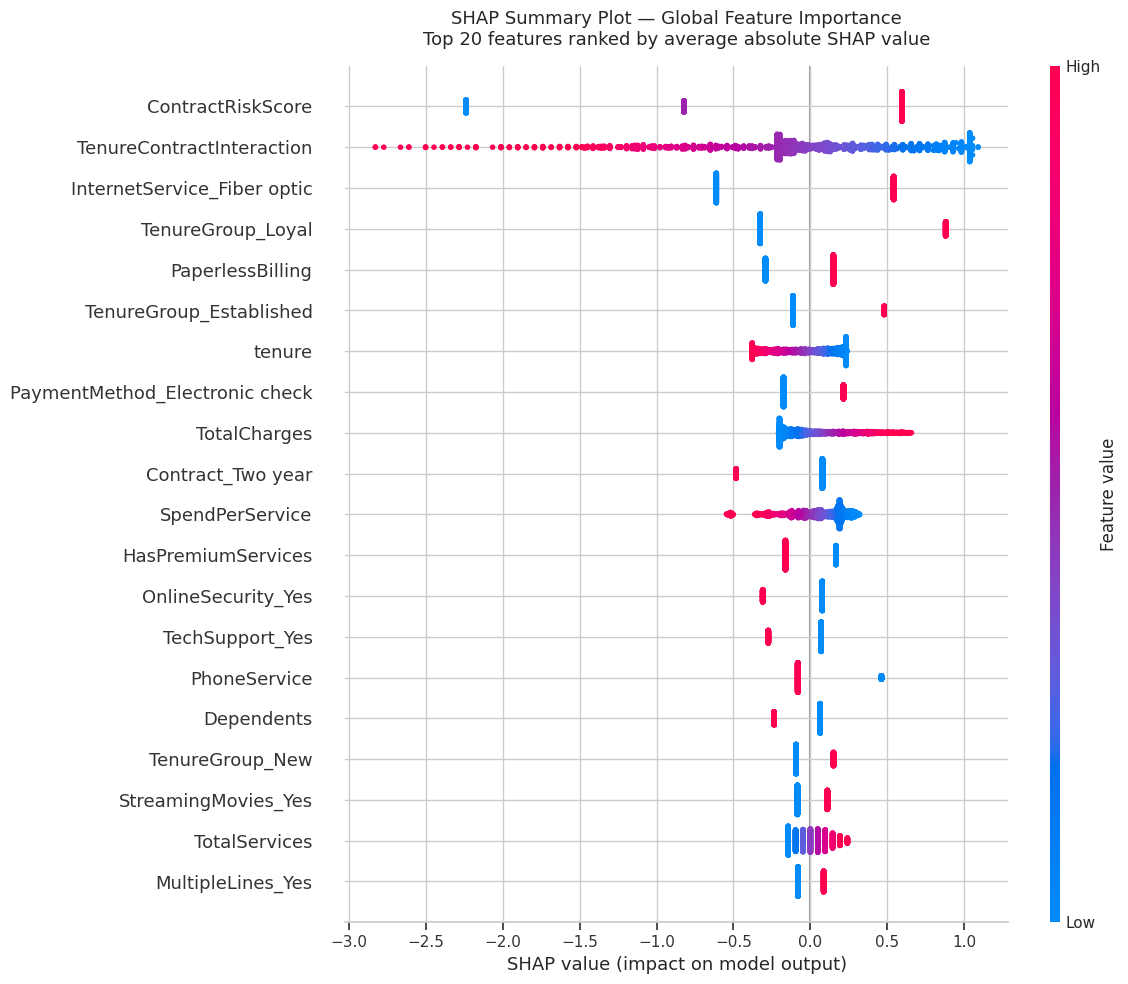


Top 15 most important features:
Rank   Feature                                  Mean |SHAP|
------------------------------------------------------------
1      ContractRiskScore                        1.0385
2      TenureContractInteraction                0.6440
3      InternetService_Fiber optic              0.5809
4      TenureGroup_Loyal                        0.5063
5      PaperlessBilling                         0.2114
6      TenureGroup_Established                  0.1945
7      tenure                                   0.1882
8      PaymentMethod_Electronic check           0.1874
9      TotalCharges                             0.1826
10     Contract_Two year                        0.1757
11     SpendPerService                          0.1650
12     HasPremiumServices                       0.1636
13     OnlineSecurity_Yes                       0.1452
14     TechSupport_Yes                          0.1316
15     PhoneService                             0.1229


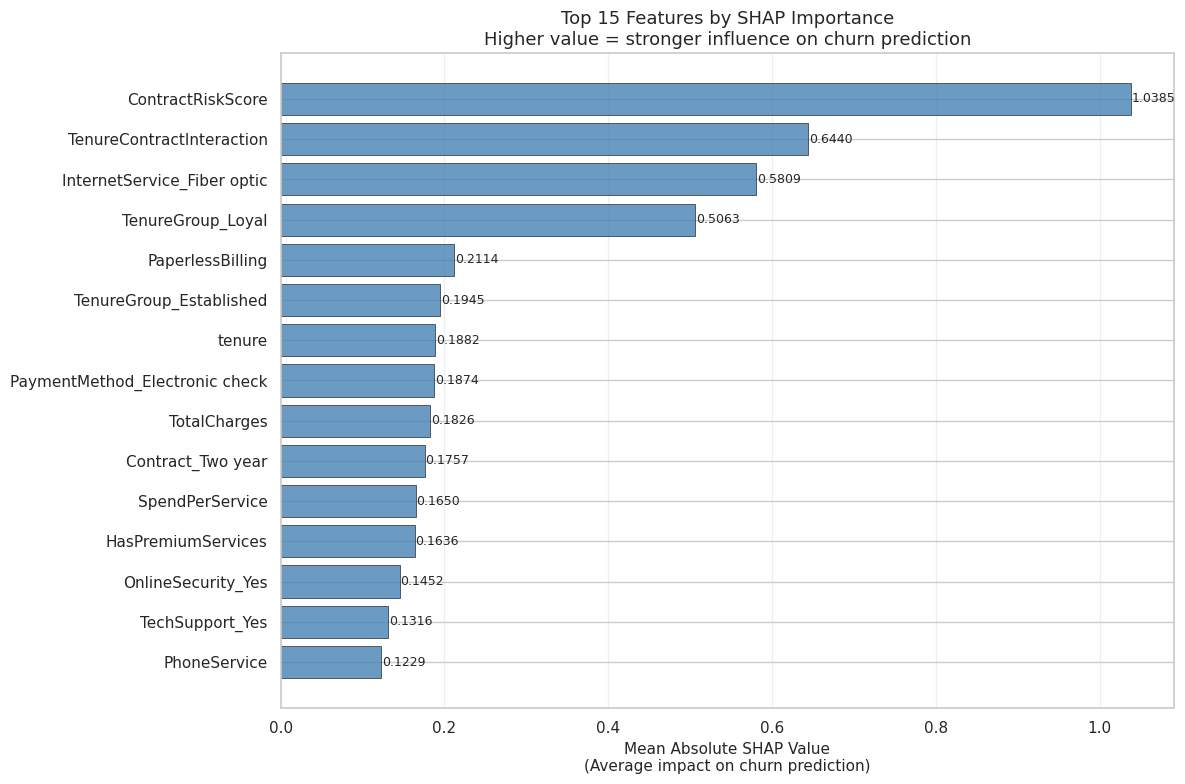


LOCAL INTERPRETABILITY — WATERFALL PLOTS

How to read a waterfall plot:
  Bottom bar  = baseline (average prediction across all customers)
  Each bar    = how much one feature pushed the prediction up or down
  Red bars    = pushed towards churn (increased probability)
  Blue bars   = pushed away from churn (decreased probability)
  Final value = the model's actual prediction for this customer

  This tells the retention team exactly WHY a customer was flagged


HIGH RISK CUSTOMER
  Churn probability : 0.7577
  Predicted         : Churn
  Actually          : Churned

  Top 8 features driving this prediction:
  Feature                                  SHAP Value   Direction
  -----------------------------------------------------------------
  ContractRiskScore                        +0.5951     Increases churn risk
  InternetService_Fiber optic              +0.5423     Increases churn risk
  TenureGroup_Loyal                        -0.3258     Decreases churn risk
  PaymentMethod_Elect

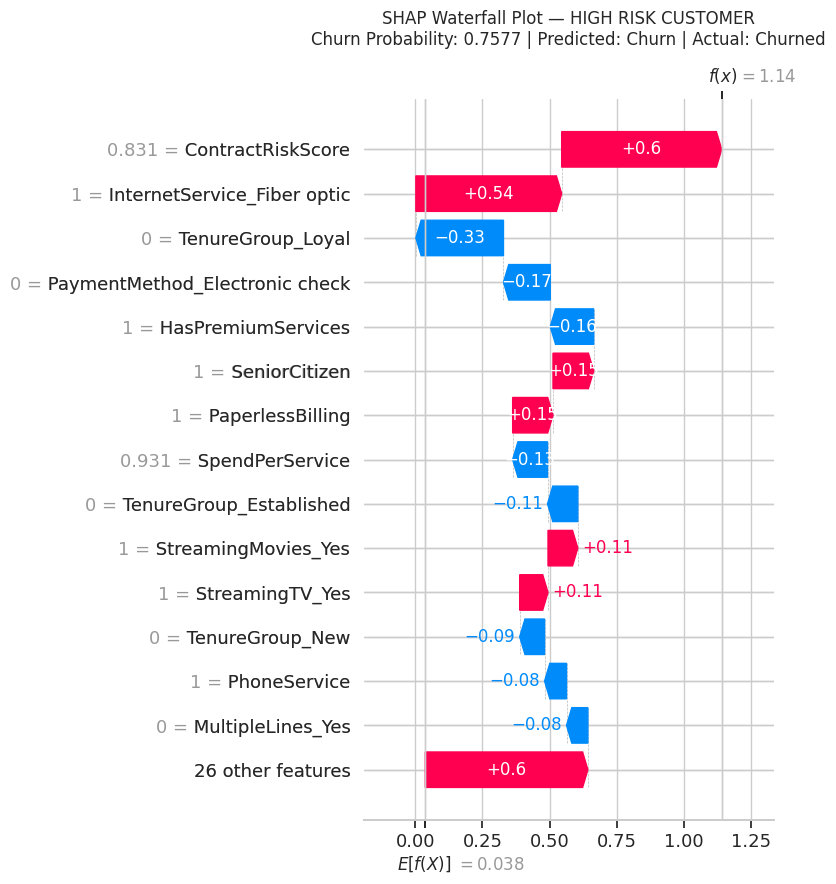


LOW RISK CUSTOMER
  Churn probability : 0.1110
  Predicted         : Stay
  Actually          : Stayed

  Top 8 features driving this prediction:
  Feature                                  SHAP Value   Direction
  -----------------------------------------------------------------
  ContractRiskScore                        -0.8217     Decreases churn risk
  InternetService_Fiber optic              -0.6115     Decreases churn risk
  TenureGroup_Established                  +0.4807     Increases churn risk
  TenureGroup_Loyal                        -0.3258     Decreases churn risk
  OnlineSecurity_Yes                       -0.3093     Decreases churn risk
  PaperlessBilling                         -0.2917     Decreases churn risk
  TechSupport_Yes                          -0.2732     Decreases churn risk
  TenureContractInteraction                -0.2151     Decreases churn risk


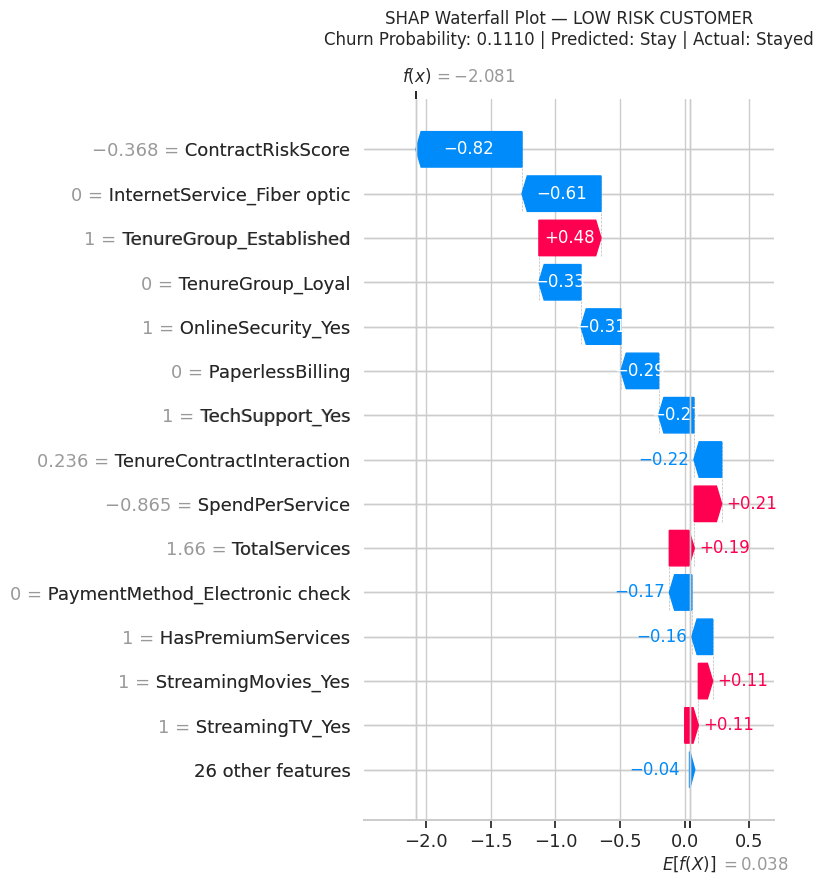


SHAP DEPENDENCE PLOTS — TOP 3 FEATURES

How to read a dependence plot:
  X axis = raw feature value
  Y axis = SHAP value for that feature
  Each dot is one customer
  Colour = value of the most interacting feature (chosen automatically)

  A downward trend means higher feature value decreases churn risk
  An upward trend means higher feature value increases churn risk
  Non-linear patterns reveal complex relationships



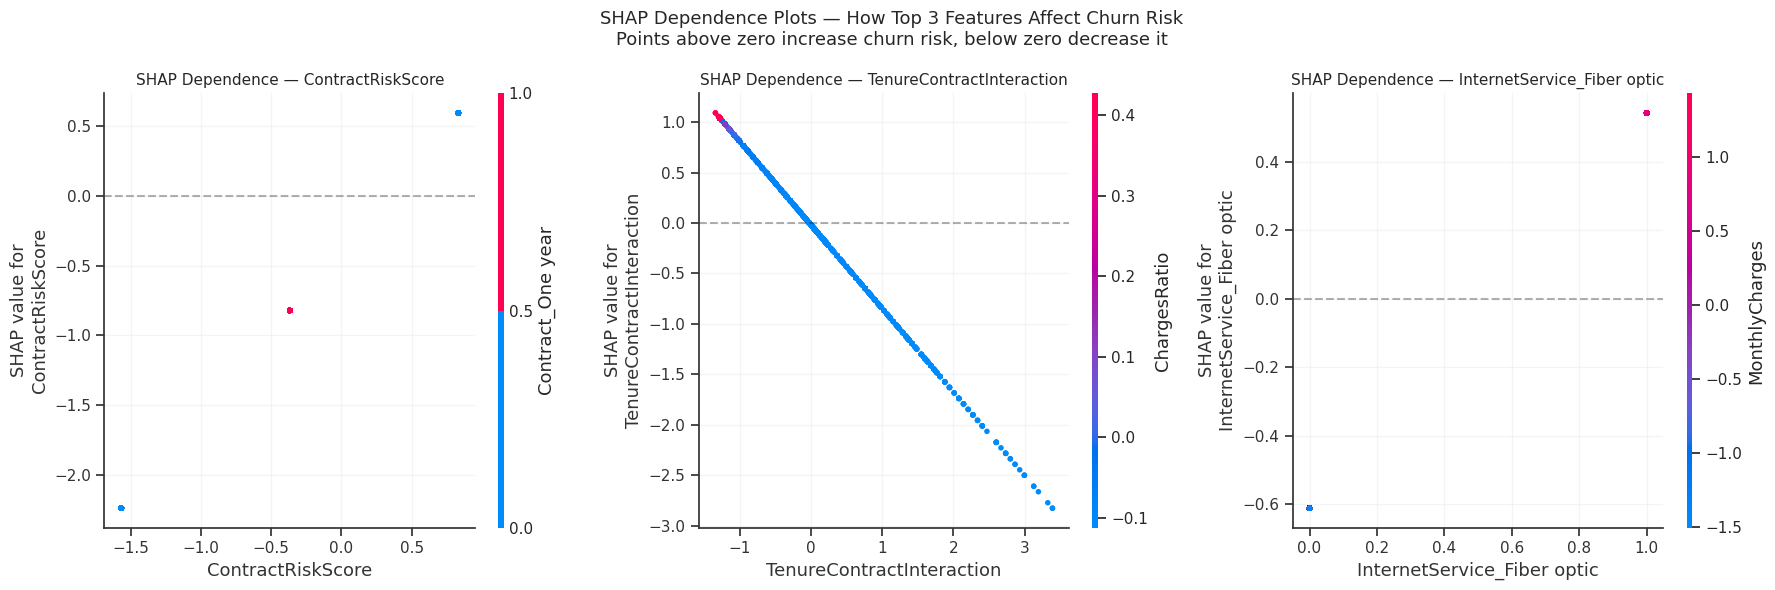


WHAT SHAP TELLS THE BUSINESS

The five strongest drivers of churn in this dataset:

1. ContractRiskScore (importance: 1.0385)
   Month to month customers are far more likely to leave. Locking customers into longer contracts dramatically reduces churn.

2. TenureContractInteraction (importance: 0.6440)
   The combination of short tenure and flexible contract is the highest risk profile in the entire dataset.

3. InternetService_Fiber optic (importance: 0.5809)
   Fiber optic customers churn more. They are tech savvy, aware of alternatives and paying premium prices.

4. TenureGroup_Loyal (importance: 0.5063)
   This feature has a mean absolute SHAP value of 0.5063

5. PaperlessBilling (importance: 0.2114)
   This feature has a mean absolute SHAP value of 0.2114

ACTIONABLE RECOMMENDATIONS

1. Target new customers immediately
   Customers in their first 3 months are at extreme risk.
   Onboarding calls and early engagement programmes should
   be prioritised for this segment.

2. Push mo

In [14]:

# =============================================================================
# CELL 14: SHAP — SHAPLEY ADDITIVE EXPLANATIONS
#
# SHAP answers two questions that standard metrics cannot:
#
# GLOBAL: Which features drive churn across all customers?
# LOCAL:  Why did the model predict THIS specific customer will churn?
#
# How SHAP works:
# For every customer and every feature SHAP calculates how much that
# feature pushed the prediction away from the baseline (average prediction).
# Positive SHAP value = pushed prediction towards churn
# Negative SHAP value = pushed prediction away from churn
#
# The baseline is the average churn probability across all customers.
# Every individual prediction is the baseline plus the sum of all
# SHAP values for that customer.
#
# We use LinearExplainer which is optimised for logistic regression.
# It is much faster than the general KernelExplainer and gives
# exact SHAP values for linear models.
# =============================================================================

# Extract the logistic regression from the best model pipeline
lr_model = best_model.named_steps['logisticregression']

# Get feature names from the preprocessing pipeline
try:
    feature_names = (
        full_pipeline
        .named_steps['preprocessor']
        .get_feature_names_out()
        .tolist()
    )
except Exception:
    feature_names = [f'feature_{i}' for i in range(X_train_processed.shape[1])]

print(f"Number of features after preprocessing : {len(feature_names)}")
print(f"Feature names:")
for i, name in enumerate(feature_names):
    print(f"  {i:>3}. {name}")

# =============================================================================
# SHAP PART 2: CALCULATE SHAP VALUES
# =============================================================================

# LinearExplainer is optimised for logistic regression
# It calculates exact SHAP values much faster than KernelExplainer
explainer   = shap.LinearExplainer(
    lr_model,
    X_train_smote,
    feature_perturbation='interventional'
)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_processed)

print(f"SHAP values calculated successfully")
print(f"Shape : {shap_values.shape}")
print(f"  Rows    : {shap_values.shape[0]} customers in test set")
print(f"  Columns : {shap_values.shape[1]} features")
print(f"\nBaseline (average churn probability) : {explainer.expected_value:.4f}")
print(f"This means without any customer information")
print(f"the model predicts {explainer.expected_value:.2%} churn probability for everyone")

# Verify SHAP values sum correctly for one customer
customer_idx   = 0
shap_sum       = explainer.expected_value + shap_values[customer_idx].sum()
print(f"\nVerification for customer {customer_idx}:")
print(f"  Baseline                    : {explainer.expected_value:.4f}")
print(f"  Sum of SHAP values          : {shap_values[customer_idx].sum():.4f}")
print(f"  Baseline + SHAP sum         : {shap_sum:.4f}")
print(f"  Model raw prediction (logit): {lr_model.decision_function(X_test_processed[[customer_idx]])[0]:.4f}")
print(f"  Actual churn probability    : {y_prob[customer_idx]:.4f}")
print(f"  Actual label                : {y_test.iloc[customer_idx]}")

# =============================================================================
# SHAP PART 3: GLOBAL INTERPRETABILITY — SUMMARY PLOT
# Which features matter most across ALL customers?
# =============================================================================

print(f"\n{'=' * 60}")
print(f"GLOBAL INTERPRETABILITY — SHAP SUMMARY PLOT")
print(f"{'=' * 60}")
print(f"""
How to read this plot:
  Each row is one feature
  Each dot is one customer
  X axis  = SHAP value (positive = pushes towards churn)
  Colour  = feature value (red = high, blue = low)
  Width   = how many customers have that SHAP value

  Features at the top have the most impact on predictions
  A red dot on the right means high feature value increases churn risk
  A blue dot on the right means low feature value increases churn risk
""")

fig = plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    show=False,
    max_display=20,
    plot_size=None
)
plt.title(
    'SHAP Summary Plot — Global Feature Importance\n'
    'Top 20 features ranked by average absolute SHAP value',
    fontsize=13, pad=15
)
plt.tight_layout()
plt.show()

# Print ranked feature importance
mean_abs_shap  = np.abs(shap_values).mean(axis=0)
feature_importance = pd.DataFrame({
    'Feature'    : feature_names,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False)

print(f"\nTop 15 most important features:")
print(f"{'Rank':<6} {'Feature':<40} {'Mean |SHAP|'}")
print("-" * 60)
for rank, (_, row) in enumerate(feature_importance.head(15).iterrows(), 1):
    print(f"{rank:<6} {row['Feature']:<40} {row['Mean |SHAP|']:.4f}")

# =============================================================================
# SHAP PART 4: GLOBAL BAR PLOT
# Cleaner view of feature importance
# =============================================================================

fig, ax = plt.subplots(figsize=(12, 8))

top_n      = 15
top_features = feature_importance.head(top_n)
colors     = ['tomato' if v > 0 else 'steelblue'
              for v in top_features['Mean |SHAP|']]

bars = ax.barh(
    range(top_n),
    top_features['Mean |SHAP|'].values,
    color='steelblue',
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5
)

ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['Feature'].values, fontsize=11)
ax.invert_yaxis()
ax.set_xlabel('Mean Absolute SHAP Value\n(Average impact on churn prediction)', fontsize=11)
ax.set_title(
    f'Top {top_n} Features by SHAP Importance\n'
    f'Higher value = stronger influence on churn prediction',
    fontsize=13
)
ax.grid(True, alpha=0.3, axis='x')

for bar, value in zip(bars, top_features['Mean |SHAP|'].values):
    ax.text(
        value + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.4f}',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

# =============================================================================
# SHAP PART 5: LOCAL INTERPRETABILITY — WATERFALL PLOTS
# Why did the model make THIS prediction for THIS customer?
# =============================================================================

print(f"\n{'=' * 60}")
print(f"LOCAL INTERPRETABILITY — WATERFALL PLOTS")
print(f"{'=' * 60}")
print(f"""
How to read a waterfall plot:
  Bottom bar  = baseline (average prediction across all customers)
  Each bar    = how much one feature pushed the prediction up or down
  Red bars    = pushed towards churn (increased probability)
  Blue bars   = pushed away from churn (decreased probability)
  Final value = the model's actual prediction for this customer

  This tells the retention team exactly WHY a customer was flagged
""")

# Find a high risk customer — someone with high churn probability
# who actually churned
high_risk_mask    = (y_prob > 0.7) & (y_test == 1)
high_risk_indices = np.where(high_risk_mask)[0]
high_risk_idx     = high_risk_indices[0] if len(high_risk_indices) > 0 else np.argmax(y_prob)

# Find a low risk customer — someone with low churn probability
# who actually stayed
low_risk_mask     = (y_prob < 0.2) & (y_test == 0)
low_risk_indices  = np.where(low_risk_mask)[0]
low_risk_idx      = low_risk_indices[0] if len(low_risk_indices) > 0 else np.argmin(y_prob)

for idx, label in [(high_risk_idx, 'HIGH RISK CUSTOMER'),
                   (low_risk_idx,  'LOW RISK CUSTOMER')]:

    churn_prob   = y_prob[idx]
    actual_label = y_test.iloc[idx]
    prediction   = 'Churn' if churn_prob >= 0.5 else 'Stay'

    print(f"\n{label}")
    print(f"  Churn probability : {churn_prob:.4f}")
    print(f"  Predicted         : {prediction}")
    print(f"  Actually          : {'Churned' if actual_label == 1 else 'Stayed'}")

    # Top contributing features for this customer
    customer_shap  = shap_values[idx]
    top_idx        = np.argsort(np.abs(customer_shap))[::-1][:8]

    print(f"\n  Top 8 features driving this prediction:")
    print(f"  {'Feature':<40} {'SHAP Value':<12} {'Direction'}")
    print(f"  {'-' * 65}")
    for i in top_idx:
        direction = 'Increases churn risk' if customer_shap[i] > 0 else 'Decreases churn risk'
        print(f"  {feature_names[i]:<40} {customer_shap[i]:>+.4f}     {direction}")

    # Waterfall plot
    explanation = shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test_processed[idx],
        feature_names=feature_names
    )

    fig, ax = plt.subplots(figsize=(12, 8))
    shap.waterfall_plot(
        explanation,
        max_display=15,
        show=False
    )
    plt.title(
        f'SHAP Waterfall Plot — {label}\n'
        f'Churn Probability: {churn_prob:.4f} | '
        f'Predicted: {prediction} | '
        f'Actual: {"Churned" if actual_label == 1 else "Stayed"}',
        fontsize=12, pad=15
    )
    plt.tight_layout()
    plt.show()

# =============================================================================
# SHAP PART 6: DEPENDENCE PLOTS
# How does one feature affect churn probability across its range?
# =============================================================================

print(f"\n{'=' * 60}")
print(f"SHAP DEPENDENCE PLOTS — TOP 3 FEATURES")
print(f"{'=' * 60}")
print(f"""
How to read a dependence plot:
  X axis = raw feature value
  Y axis = SHAP value for that feature
  Each dot is one customer
  Colour = value of the most interacting feature (chosen automatically)

  A downward trend means higher feature value decreases churn risk
  An upward trend means higher feature value increases churn risk
  Non-linear patterns reveal complex relationships
""")

top3_features = feature_importance.head(3)['Feature'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, feature in zip(axes, top3_features):
    feature_idx = feature_names.index(feature)

    shap.dependence_plot(
        feature,
        shap_values,
        X_test_processed,
        feature_names=feature_names,
        ax=ax,
        show=False
    )

    ax.set_title(f'SHAP Dependence — {feature}', fontsize=11)
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
    ax.grid(True, alpha=0.2)

plt.suptitle(
    'SHAP Dependence Plots — How Top 3 Features Affect Churn Risk\n'
    'Points above zero increase churn risk, below zero decrease it',
    fontsize=13
)
plt.tight_layout()
plt.show()

# =============================================================================
# SHAP PART 7: BUSINESS SUMMARY
# Translate SHAP findings into plain business language
# =============================================================================

print(f"\n{'=' * 60}")
print(f"WHAT SHAP TELLS THE BUSINESS")
print(f"{'=' * 60}")

top5 = feature_importance.head(5)

print(f"\nThe five strongest drivers of churn in this dataset:\n")

business_explanations = {
    'tenure'                   : 'Newer customers churn significantly more. The first 12 months are the highest risk window.',
    'ContractRiskScore'        : 'Month to month customers are far more likely to leave. Locking customers into longer contracts dramatically reduces churn.',
    'TenureContractInteraction': 'The combination of short tenure and flexible contract is the highest risk profile in the entire dataset.',
    'MonthlyCharges'           : 'Higher paying customers are more likely to churn. They are more price sensitive and more aware of competitor pricing.',
    'TotalCharges'             : 'Lower total charges (newer customers) correlates strongly with higher churn risk.',
    'ChargesRatio'             : 'Customers whose monthly charges are high relative to their lifetime spend are at elevated risk.',
    'InternetService_Fiber optic': 'Fiber optic customers churn more. They are tech savvy, aware of alternatives and paying premium prices.',
    'Contract_Two year'        : 'Two year contracts are a strong churn deterrent. These customers almost never leave.',
    'IsAutomatedPayment'       : 'Customers on automatic payment are passively committed and less likely to actively reconsider.',
    'TotalServices'            : 'Customers using more services have higher switching costs and churn less.'
}

for rank, (_, row) in enumerate(top5.iterrows(), 1):
    feature = row['Feature']
    importance = row['Mean |SHAP|']
    explanation = business_explanations.get(
        feature,
        f'This feature has a mean absolute SHAP value of {importance:.4f}'
    )
    print(f"{rank}. {feature} (importance: {importance:.4f})")
    print(f"   {explanation}\n")

print(f"{'=' * 60}")
print(f"ACTIONABLE RECOMMENDATIONS")
print(f"{'=' * 60}")
print(f"""
1. Target new customers immediately
   Customers in their first 3 months are at extreme risk.
   Onboarding calls and early engagement programmes should
   be prioritised for this segment.

2. Push month to month customers towards annual contracts
   Offering a discount to switch from monthly to annual
   contracts would significantly reduce churn. The SHAP
   values show contract type is one of the strongest signals.

3. Watch high paying fiber optic customers closely
   This segment pays the most and churns the most.
   Competitor pricing alerts and loyalty rewards targeted
   at fiber customers would have the highest ROI.

4. Promote premium add-on services
   Customers with security, backup and support add-ons churn
   less. Bundling promotions that encourage adoption of these
   services would increase customer stickiness.

5. Enrol customers in automatic payment
   Automatic payment customers are significantly more loyal.
   Incentivising customers to switch to bank transfer or
   credit card automatic payment would reduce churn passively.
""")

CHURN PREDICTIONS FOR TEST CUSTOMERS

Customer : New Month-to-Month Fiber Customer
  Churn Probability  : 93.74%
  Risk Category      : Critical Risk
  Recommended Action : Immediate intervention required

Customer : Long Tenure Two Year Contract Customer
  Churn Probability  : 2.19%
  Risk Category      : Low Risk
  Recommended Action : No action needed

Customer : Senior Citizen High Charges No Security
  Churn Probability  : 94.88%
  Risk Category      : Critical Risk
  Recommended Action : Immediate intervention required

Customer : Mid Tenure One Year Contract DSL Customer
  Churn Probability  : 10.15%
  Risk Category      : Low Risk
  Recommended Action : No action needed

Customer : No Internet Service Phone Only Customer
  Churn Probability  : 0.91%
  Risk Category      : Low Risk
  Recommended Action : No action needed

SUMMARY TABLE


,Customer Profile,Churn Probability,Risk Category,Recommended Action
0,New Month-to-Month Fiber Customer,93.74%,Critical Risk,Immediate intervention required
1,Long Tenure Two Year Contract Customer,2.19%,Low Risk,No action needed
2,Senior Citizen High Charges No Security,94.88%,Critical Risk,Immediate intervention required
3,Mid Tenure One Year Contract DSL Customer,10.15%,Low Risk,No action needed
4,No Internet Service Phone Only Customer,0.91%,Low Risk,No action needed


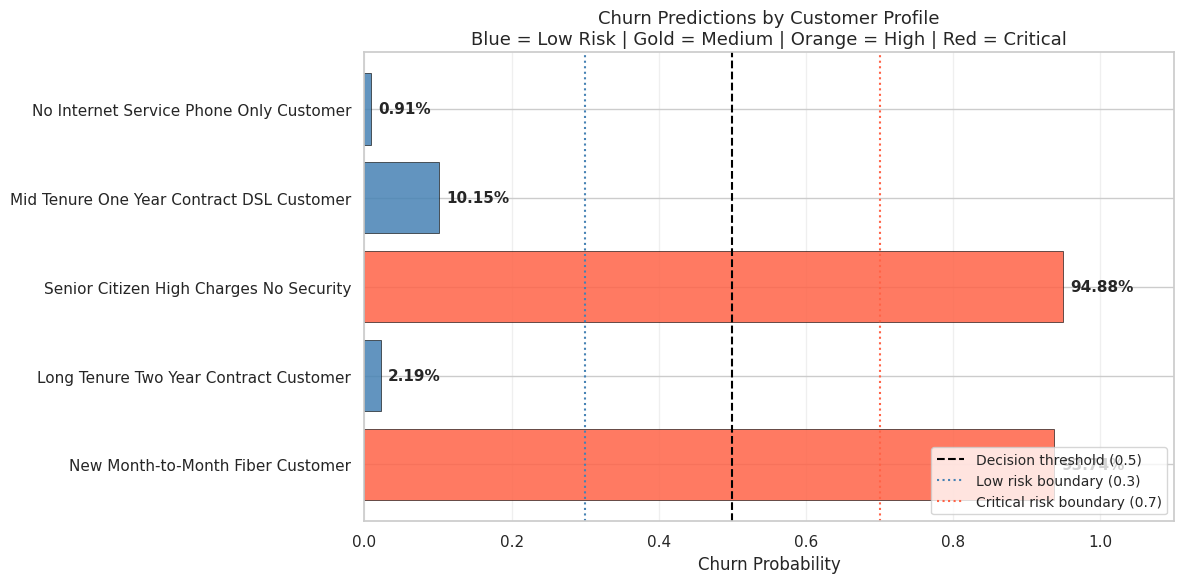


BATCH PREDICTION — FULL TEST SET (1405 customers)

Risk Category Distribution:
  Low Risk        :  615 customers (43.8%)
  Critical Risk   :  322 customers (22.9%)
  Medium Risk     :  255 customers (18.1%)
  High Risk       :  213 customers (15.2%)


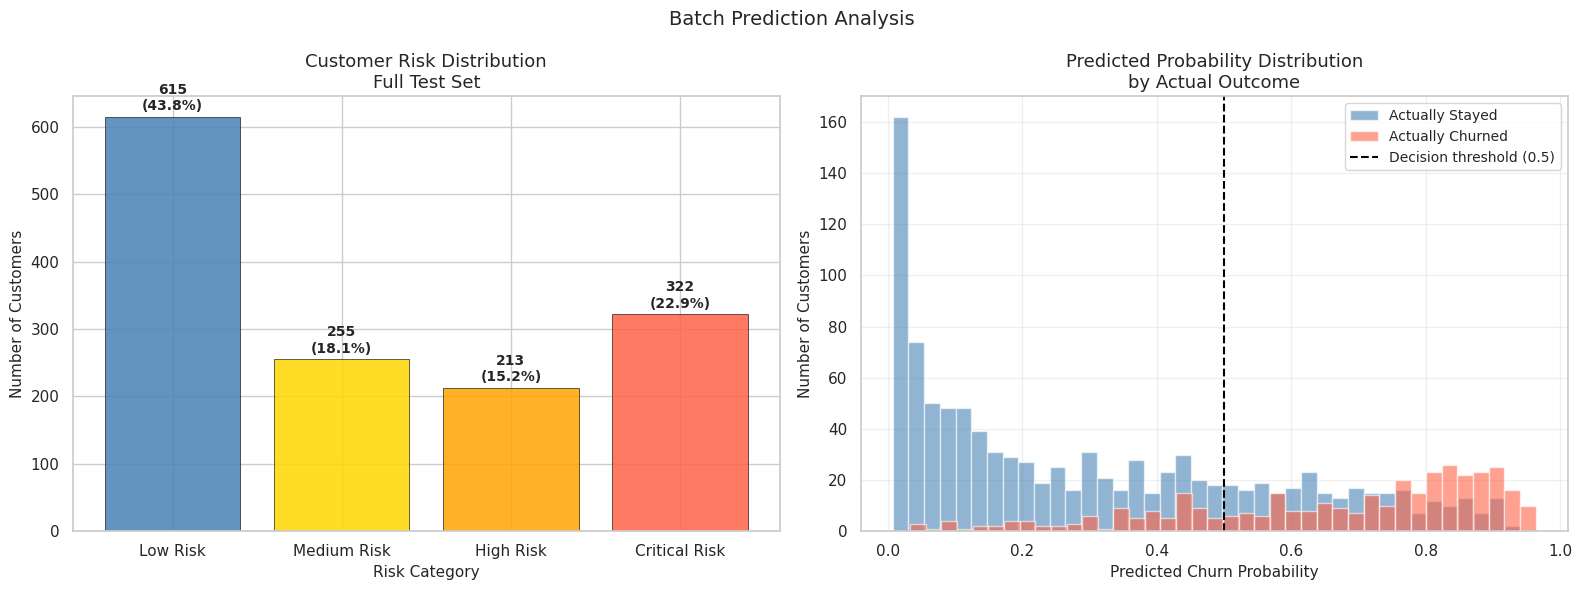


Correct predictions : 1058 out of 1405
Overall accuracy    : 75.30%


In [15]:

# =============================================================================
# CELL 15: PREDICTING ON NEW CUSTOMERS
#
# This is where the model earns its value in production.
# We take raw customer data exactly as it comes from the business
# system and return a churn probability and risk category.
#
# The full pipeline handles everything internally:
#   Raw data → Feature engineering → Encoding → Scaling → Prediction
#
# The business never needs to know about any of the preprocessing.
# They just pass in a customer profile and get back a probability.
# =============================================================================

# Build the complete end to end prediction pipeline
# Combines preprocessing and logistic regression into one object
from sklearn.pipeline import Pipeline as SklearnPipeline

lr_model_final = best_model.named_steps['logisticregression']

prediction_pipeline = SklearnPipeline(steps=[
    ('preprocessing',      full_pipeline),
    ('logisticregression', lr_model_final)
])

# Risk category function
def get_risk_category(probability):
    if probability < 0.30:
        return 'Low Risk',      'No action needed'
    elif probability < 0.50:
        return 'Medium Risk',   'Schedule check in call'
    elif probability < 0.70:
        return 'High Risk',     'Offer loyalty discount'
    else:
        return 'Critical Risk', 'Immediate intervention required'


# Predict function for a single customer
def predict_customer(customer_data, pipeline):
    df_customer    = pd.DataFrame([customer_data])
    churn_prob     = pipeline.predict_proba(df_customer)[:, 1][0]
    risk, action   = get_risk_category(churn_prob)
    return {
        'Churn Probability' : f'{churn_prob:.2%}',
        'Risk Category'     : risk,
        'Recommended Action': action
    }


# =============================================================================
# TEST CUSTOMERS
# We test five customers representing different risk profiles
# to show the model behaves correctly across the full spectrum
# =============================================================================

customers = {

    'New Month-to-Month Fiber Customer': {
        'gender'           : 'Female',
        'SeniorCitizen'    : 0,
        'Partner'          : 'No',
        'Dependents'       : 'No',
        'tenure'           : 2,
        'PhoneService'     : 'Yes',
        'MultipleLines'    : 'No',
        'InternetService'  : 'Fiber optic',
        'OnlineSecurity'   : 'No',
        'OnlineBackup'     : 'No',
        'DeviceProtection' : 'No',
        'TechSupport'      : 'No',
        'StreamingTV'      : 'Yes',
        'StreamingMovies'  : 'Yes',
        'Contract'         : 'Month-to-month',
        'PaperlessBilling' : 'Yes',
        'PaymentMethod'    : 'Electronic check',
        'MonthlyCharges'   : 85.50,
        'TotalCharges'     : 171.00
    },

    'Long Tenure Two Year Contract Customer': {
        'gender'           : 'Male',
        'SeniorCitizen'    : 0,
        'Partner'          : 'Yes',
        'Dependents'       : 'Yes',
        'tenure'           : 60,
        'PhoneService'     : 'Yes',
        'MultipleLines'    : 'Yes',
        'InternetService'  : 'DSL',
        'OnlineSecurity'   : 'Yes',
        'OnlineBackup'     : 'Yes',
        'DeviceProtection' : 'Yes',
        'TechSupport'      : 'Yes',
        'StreamingTV'      : 'No',
        'StreamingMovies'  : 'No',
        'Contract'         : 'Two year',
        'PaperlessBilling' : 'No',
        'PaymentMethod'    : 'Bank transfer (automatic)',
        'MonthlyCharges'   : 65.00,
        'TotalCharges'     : 3900.00
    },

    'Senior Citizen High Charges No Security': {
        'gender'           : 'Male',
        'SeniorCitizen'    : 1,
        'Partner'          : 'No',
        'Dependents'       : 'No',
        'tenure'           : 8,
        'PhoneService'     : 'Yes',
        'MultipleLines'    : 'Yes',
        'InternetService'  : 'Fiber optic',
        'OnlineSecurity'   : 'No',
        'OnlineBackup'     : 'No',
        'DeviceProtection' : 'No',
        'TechSupport'      : 'No',
        'StreamingTV'      : 'Yes',
        'StreamingMovies'  : 'Yes',
        'Contract'         : 'Month-to-month',
        'PaperlessBilling' : 'Yes',
        'PaymentMethod'    : 'Electronic check',
        'MonthlyCharges'   : 95.00,
        'TotalCharges'     : 760.00
    },

    'Mid Tenure One Year Contract DSL Customer': {
        'gender'           : 'Female',
        'SeniorCitizen'    : 0,
        'Partner'          : 'Yes',
        'Dependents'       : 'No',
        'tenure'           : 24,
        'PhoneService'     : 'Yes',
        'MultipleLines'    : 'No',
        'InternetService'  : 'DSL',
        'OnlineSecurity'   : 'Yes',
        'OnlineBackup'     : 'No',
        'DeviceProtection' : 'Yes',
        'TechSupport'      : 'No',
        'StreamingTV'      : 'No',
        'StreamingMovies'  : 'No',
        'Contract'         : 'One year',
        'PaperlessBilling' : 'Yes',
        'PaymentMethod'    : 'Credit card (automatic)',
        'MonthlyCharges'   : 55.00,
        'TotalCharges'     : 1320.00
    },

    'No Internet Service Phone Only Customer': {
        'gender'           : 'Male',
        'SeniorCitizen'    : 0,
        'Partner'          : 'Yes',
        'Dependents'       : 'Yes',
        'tenure'           : 45,
        'PhoneService'     : 'Yes',
        'MultipleLines'    : 'No',
        'InternetService'  : 'No',
        'OnlineSecurity'   : 'No internet service',
        'OnlineBackup'     : 'No internet service',
        'DeviceProtection' : 'No internet service',
        'TechSupport'      : 'No internet service',
        'StreamingTV'      : 'No internet service',
        'StreamingMovies'  : 'No internet service',
        'Contract'         : 'Two year',
        'PaperlessBilling' : 'No',
        'PaymentMethod'    : 'Mailed check',
        'MonthlyCharges'   : 20.00,
        'TotalCharges'     : 900.00
    }
}

# Run predictions for all customers
print(f"{'=' * 70}")
print(f"CHURN PREDICTIONS FOR TEST CUSTOMERS")
print(f"{'=' * 70}")

results = []

for customer_name, customer_data in customers.items():
    prediction = predict_customer(customer_data, prediction_pipeline)
    results.append({
        'Customer Profile'  : customer_name,
        **prediction
    })

    print(f"\nCustomer : {customer_name}")
    print(f"  Churn Probability  : {prediction['Churn Probability']}")
    print(f"  Risk Category      : {prediction['Risk Category']}")
    print(f"  Recommended Action : {prediction['Recommended Action']}")

# Summary table
print(f"\n{'=' * 70}")
print(f"SUMMARY TABLE")
print(f"{'=' * 70}")
results_df = pd.DataFrame(results)
display(results_df)

# Visualise predictions
fig, ax = plt.subplots(figsize=(12, 6))

probs  = [float(r['Churn Probability'].strip('%')) / 100 for r in results]
names  = [r['Customer Profile'] for r in results]
colors = []

for p in probs:
    if p < 0.30:
        colors.append('steelblue')
    elif p < 0.50:
        colors.append('gold')
    elif p < 0.70:
        colors.append('orange')
    else:
        colors.append('tomato')

bars = ax.barh(names, probs, color=colors, alpha=0.85,
               edgecolor='black', linewidth=0.5)

ax.axvline(x=0.5, color='black', linestyle='--',
           linewidth=1.5, label='Decision threshold (0.5)')
ax.axvline(x=0.3, color='steelblue', linestyle=':',
           linewidth=1.5, label='Low risk boundary (0.3)')
ax.axvline(x=0.7, color='tomato', linestyle=':',
           linewidth=1.5, label='Critical risk boundary (0.7)')

for bar, prob in zip(bars, probs):
    ax.text(
        prob + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{prob:.2%}',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

ax.set_xlabel('Churn Probability', fontsize=12)
ax.set_title(
    'Churn Predictions by Customer Profile\n'
    'Blue = Low Risk | Gold = Medium | Orange = High | Red = Critical',
    fontsize=13
)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1.1])
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# =============================================================================
# BATCH PREDICTION ON FULL TEST SET
# =============================================================================

print(f"\n{'=' * 70}")
print(f"BATCH PREDICTION — FULL TEST SET ({len(X_test)} customers)")
print(f"{'=' * 70}")

# Predict on raw test features
batch_probs = prediction_pipeline.predict_proba(X_test)[:, 1]

# Assign risk categories
risk_categories  = []
recommendations  = []

for prob in batch_probs:
    risk, action = get_risk_category(prob)
    risk_categories.append(risk)
    recommendations.append(action)

batch_results = X_test.copy()
batch_results['ChurnProbability'] = np.round(batch_probs, 4)
batch_results['RiskCategory']     = risk_categories
batch_results['Recommendation']   = recommendations
batch_results['ActualChurn']      = y_test.values
batch_results['CorrectPrediction'] = (
    (batch_probs >= 0.5).astype(int) == y_test.values
).astype(int)

# Risk distribution
print(f"\nRisk Category Distribution:")
risk_dist = pd.Series(risk_categories).value_counts()
for category, count in risk_dist.items():
    pct = count / len(risk_categories) * 100
    print(f"  {category:<15} : {count:>4} customers ({pct:.1f}%)")

# Visualise risk distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

risk_order  = ['Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk']
risk_colors = ['steelblue', 'gold', 'orange', 'tomato']
risk_counts = [risk_dist.get(r, 0) for r in risk_order]

axes[0].bar(
    risk_order, risk_counts,
    color=risk_colors,
    alpha=0.85,
    edgecolor='black',
    linewidth=0.5
)
axes[0].set_title('Customer Risk Distribution\nFull Test Set', fontsize=13)
axes[0].set_ylabel('Number of Customers', fontsize=11)
axes[0].set_xlabel('Risk Category', fontsize=11)
for i, (count, pct) in enumerate(zip(risk_counts, [c/len(risk_categories)*100 for c in risk_counts])):
    axes[0].text(i, count + 10, f'{count}\n({pct:.1f}%)',
                 ha='center', fontweight='bold', fontsize=10)

# Churn probability distribution
axes[1].hist(
    batch_probs[y_test == 0],
    bins=40, alpha=0.6,
    color='steelblue', label='Actually Stayed'
)
axes[1].hist(
    batch_probs[y_test == 1],
    bins=40, alpha=0.6,
    color='tomato', label='Actually Churned'
)
axes[1].axvline(
    x=0.5, color='black',
    linestyle='--', linewidth=1.5,
    label='Decision threshold (0.5)'
)
axes[1].set_xlabel('Predicted Churn Probability', fontsize=11)
axes[1].set_ylabel('Number of Customers', fontsize=11)
axes[1].set_title(
    'Predicted Probability Distribution\nby Actual Outcome',
    fontsize=13
)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Batch Prediction Analysis', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nCorrect predictions : {batch_results['CorrectPrediction'].sum()} out of {len(batch_results)}")
print(f"Overall accuracy    : {batch_results['CorrectPrediction'].mean():.2%}")

TELECOM CHURN PREDICTION — BUSINESS SUMMARY

MODEL PERFORMANCE IN PLAIN ENGLISH

We tested the model on 1405 customers it had never seen before.
Of those 1405 customers 372 actually churned.

The model:
  Correctly identified : 280 churners (75.3% of all churners)
  Missed completely    : 92 churners (24.7% of all churners)
  False alarms         : 255 loyal customers incorrectly flagged
  Correctly ignored    : 778 loyal customers

In plain terms — for every 4 customers about to leave
the model catches 3 of them before they go.


BUSINESS COST BENEFIT ANALYSIS

Assumptions:
  Average customer lifetime value : $1,200
  Cost of retention offer         : $50

Revenue saved from caught churners:
  280 churners caught x $1,200 lifetime value
  = $336,000

Cost of retention offers:
  280 offers sent to real churners x $50
  = $14,000

Cost of false alarms:
  255 offers sent to loyal customers x $50
  = $12,750

Net benefit of deploying this model:
  $336,000 - $14,000 - $12,750
  = $309,250

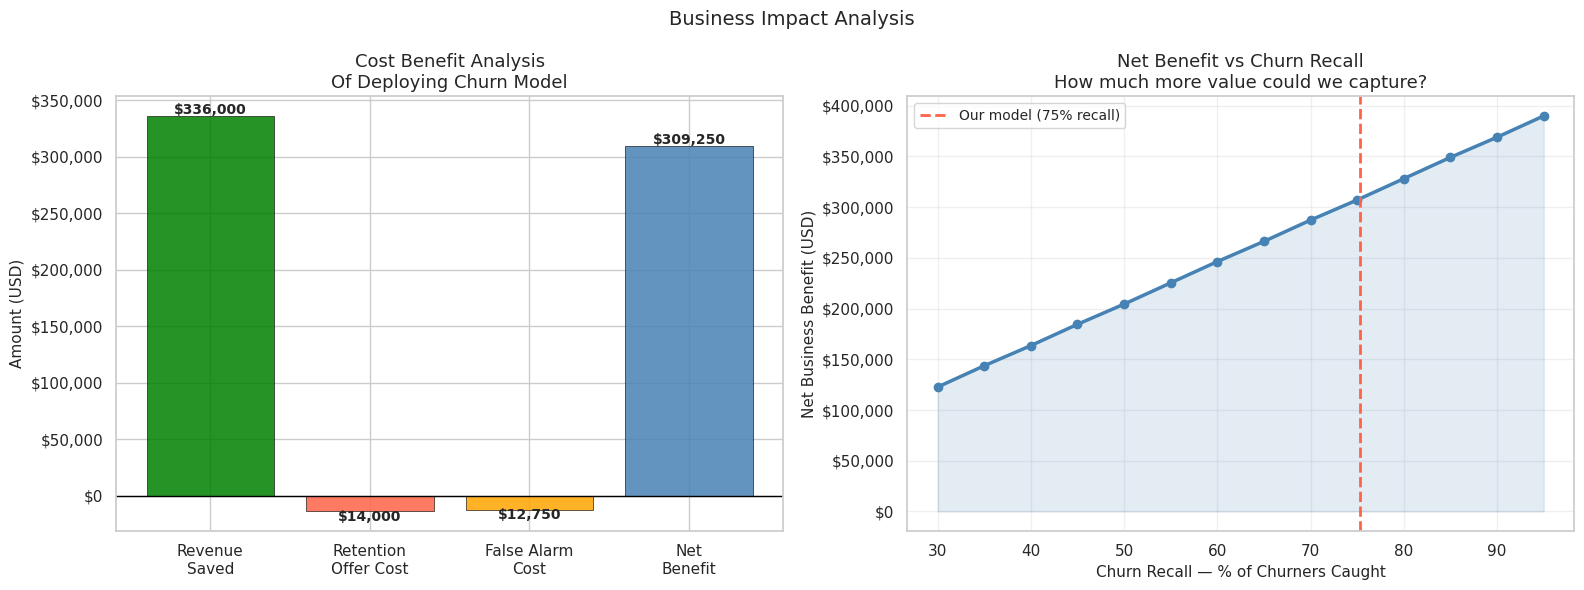


RISK BASED ACTION PLAN

Based on the model predictions on the test set:

  Low Risk — 615 customers
    Action  : No immediate action needed
    Detail  : Monitor quarterly. These customers are stable and loyal.
    Budget  : $0 per customer = $0 total

  Medium Risk — 255 customers
    Action  : Proactive check in call
    Detail  : A simple satisfaction call can prevent escalation to high risk.
    Budget  : $10 per customer = $2,550 total

  High Risk — 213 customers
    Action  : Personalised loyalty offer
    Detail  : Targeted discount or service upgrade based on usage pattern.
    Budget  : $50 per customer = $10,650 total

  Critical Risk — 322 customers
    Action  : Immediate senior retention specialist call
    Detail  : These customers are very likely to leave within 30 days.
    Budget  : $100 per customer = $32,200 total

  Total intervention budget : $45,400

FINAL MODEL SCORECARD

  Dataset          : IBM Telco Customer Churn
  Total customers  : 7,021
  Training set  

In [16]:

# =============================================================================
# CELL 16: BUSINESS SUMMARY
#
# This cell translates everything we built into language a business
# stakeholder can understand without any machine learning knowledge.
# Numbers, costs, revenue impact and clear recommendations.
# =============================================================================

print("=" * 70)
print("TELECOM CHURN PREDICTION — BUSINESS SUMMARY")
print("=" * 70)

# =============================================================================
# PART 1: MODEL PERFORMANCE IN PLAIN ENGLISH
# =============================================================================

tp = int(((batch_probs >= 0.5) & (y_test == 1)).sum())
fp = int(((batch_probs >= 0.5) & (y_test == 0)).sum())
fn = int(((batch_probs < 0.5) & (y_test == 1)).sum())
tn = int(((batch_probs < 0.5) & (y_test == 0)).sum())

total_actual_churners = tp + fn
total_customers       = len(y_test)

print(f"""
MODEL PERFORMANCE IN PLAIN ENGLISH
{'=' * 70}

We tested the model on {total_customers} customers it had never seen before.
Of those {total_customers} customers {total_actual_churners} actually churned.

The model:
  Correctly identified : {tp} churners ({tp/total_actual_churners:.1%} of all churners)
  Missed completely    : {fn} churners ({fn/total_actual_churners:.1%} of all churners)
  False alarms         : {fp} loyal customers incorrectly flagged
  Correctly ignored    : {tn} loyal customers

In plain terms — for every 4 customers about to leave
the model catches 3 of them before they go.
""")

# =============================================================================
# PART 2: BUSINESS COST BENEFIT ANALYSIS
# =============================================================================

# Industry standard assumptions for telecom
avg_customer_lifetime_value = 1200  # dollars
retention_offer_cost        = 50    # dollars per offer
false_alarm_cost            = 50    # dollars per unnecessary offer

revenue_saved    = tp * avg_customer_lifetime_value
retention_cost   = tp * retention_offer_cost
false_alarm_bill = fp * false_alarm_cost
net_benefit      = revenue_saved - retention_cost - false_alarm_bill
missed_revenue   = fn * avg_customer_lifetime_value

print(f"""
BUSINESS COST BENEFIT ANALYSIS
{'=' * 70}

Assumptions:
  Average customer lifetime value : ${avg_customer_lifetime_value:,}
  Cost of retention offer         : ${retention_offer_cost:,}

Revenue saved from caught churners:
  {tp} churners caught x ${avg_customer_lifetime_value:,} lifetime value
  = ${revenue_saved:,}

Cost of retention offers:
  {tp} offers sent to real churners x ${retention_offer_cost:,}
  = ${retention_cost:,}

Cost of false alarms:
  {fp} offers sent to loyal customers x ${false_alarm_cost:,}
  = ${false_alarm_bill:,}

Net benefit of deploying this model:
  ${revenue_saved:,} - ${retention_cost:,} - ${false_alarm_bill:,}
  = ${net_benefit:,}

Revenue lost from missed churners:
  {fn} churners missed x ${avg_customer_lifetime_value:,}
  = ${missed_revenue:,}

Return on investment:
  Every dollar spent on retention offers returns
  ${net_benefit / (retention_cost + false_alarm_bill):.1f} in saved revenue
""")

# Visualise cost benefit
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Cost benefit breakdown
categories = [
    'Revenue\nSaved',
    'Retention\nOffer Cost',
    'False Alarm\nCost',
    'Net\nBenefit'
]
values = [revenue_saved, -retention_cost, -false_alarm_bill, net_benefit]
colors = ['green', 'tomato', 'orange', 'steelblue']

bars = axes[0].bar(
    categories, values,
    color=colors,
    alpha=0.85,
    edgecolor='black',
    linewidth=0.5
)
axes[0].axhline(y=0, color='black', linewidth=1)
axes[0].set_title('Cost Benefit Analysis\nOf Deploying Churn Model', fontsize=13)
axes[0].set_ylabel('Amount (USD)', fontsize=11)
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}')
)

for bar, value in zip(bars, values):
    ypos = value + 2000 if value >= 0 else value - 8000
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        ypos,
        f'${abs(value):,}',
        ha='center',
        fontweight='bold',
        fontsize=10
    )

# What happens at different retention rates
retention_rates  = np.arange(0.3, 1.0, 0.05)
net_benefits     = []

for rate in retention_rates:
    caught   = int(total_actual_churners * rate)
    missed   = total_actual_churners - caught
    false_al = int(caught * (fp / (tp + 1)))
    benefit  = (caught * avg_customer_lifetime_value
                - caught * retention_offer_cost
                - false_al * false_alarm_cost)
    net_benefits.append(benefit)

axes[1].plot(
    retention_rates * 100,
    net_benefits,
    'o-',
    color='steelblue',
    linewidth=2.5,
    markersize=6
)
axes[1].axvline(
    x=tp/total_actual_churners * 100,
    color='tomato',
    linestyle='--',
    linewidth=2,
    label=f'Our model ({tp/total_actual_churners:.0%} recall)'
)
axes[1].fill_between(
    retention_rates * 100,
    net_benefits,
    alpha=0.15,
    color='steelblue'
)
axes[1].set_xlabel('Churn Recall — % of Churners Caught', fontsize=11)
axes[1].set_ylabel('Net Business Benefit (USD)', fontsize=11)
axes[1].set_title(
    'Net Benefit vs Churn Recall\nHow much more value could we capture?',
    fontsize=13
)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}')
)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Business Impact Analysis', fontsize=14)
plt.tight_layout()
plt.show()

# =============================================================================
# PART 3: RISK BASED ACTION PLAN
# =============================================================================

print(f"""
RISK BASED ACTION PLAN
{'=' * 70}

Based on the model predictions on the test set:
""")

risk_action_data = {
    'Low Risk'     : {
        'count'      : risk_dist.get('Low Risk', 0),
        'color'      : 'steelblue',
        'action'     : 'No immediate action needed',
        'detail'     : 'Monitor quarterly. These customers are stable and loyal.',
        'budget'     : 0
    },
    'Medium Risk'  : {
        'count'      : risk_dist.get('Medium Risk', 0),
        'color'      : 'gold',
        'action'     : 'Proactive check in call',
        'detail'     : 'A simple satisfaction call can prevent escalation to high risk.',
        'budget'     : 10
    },
    'High Risk'    : {
        'count'      : risk_dist.get('High Risk', 0),
        'color'      : 'orange',
        'action'     : 'Personalised loyalty offer',
        'detail'     : 'Targeted discount or service upgrade based on usage pattern.',
        'budget'     : 50
    },
    'Critical Risk': {
        'count'      : risk_dist.get('Critical Risk', 0),
        'color'      : 'tomato',
        'action'     : 'Immediate senior retention specialist call',
        'detail'     : 'These customers are very likely to leave within 30 days.',
        'budget'     : 100
    }
}

total_intervention_cost = 0

for category, data in risk_action_data.items():
    cost = data['count'] * data['budget']
    total_intervention_cost += cost
    print(f"  {category} — {data['count']} customers")
    print(f"    Action  : {data['action']}")
    print(f"    Detail  : {data['detail']}")
    print(f"    Budget  : ${data['budget']} per customer = ${cost:,} total")
    print()

print(f"  Total intervention budget : ${total_intervention_cost:,}")

# =============================================================================
# PART 4: FINAL MODEL SCORECARD
# =============================================================================

print(f"""
FINAL MODEL SCORECARD
{'=' * 70}

  Dataset          : IBM Telco Customer Churn
  Total customers  : {len(df_clean):,}
  Training set     : {len(X_train):,} customers
  Test set         : {len(X_test):,} customers
  Churn rate       : {y.mean():.1%}

  Algorithm        : Logistic Regression with L1 regularization
  Best parameters  : C=1, penalty=l1, solver=saga
  Class imbalance  : Handled with SMOTE + class_weight=balanced
  Cross validation : 5-fold Stratified K-Fold

  PERFORMANCE METRICS (test set)
  ROC AUC Score    : {auc_score:.4f}
  Average Precision: {avg_precision:.4f}
  Churn Recall     : {tp/total_actual_churners:.4f}
  Churn Precision  : {tp/(tp+fp):.4f}
  Churn F1 Score   : {2*(tp/(tp+fp))*(tp/total_actual_churners)/((tp/(tp+fp))+(tp/total_actual_churners)):.4f}

  BUSINESS IMPACT (test set extrapolation)
  Churners caught  : {tp} of {total_actual_churners}
  Revenue saved    : ${revenue_saved:,}
  Net benefit      : ${net_benefit:,}
  ROI              : {net_benefit/(retention_cost+false_alarm_bill):.1f}x

  TOP 5 CHURN DRIVERS (from SHAP analysis)
""")

for rank, (_, row) in enumerate(feature_importance.head(5).iterrows(), 1):
    print(f"  {rank}. {row['Feature']} (importance: {row['Mean |SHAP|']:.4f})")

print(f"""
  FIVE BUSINESS RECOMMENDATIONS
  1. Engage new customers immediately in first 90 days
  2. Convert month to month customers to annual contracts
  3. Monitor high paying fiber optic customers closely
  4. Promote premium add-on service bundles
  5. Incentivise automatic payment enrollment
""")

print("=" * 70)
print("NOTEBOOK COMPLETE")
print("=" * 70)